In [5]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from tsa_course.lecture1 import fft_analysis
from tsa_course.lecture2 import run_sequence_plot
from scipy import signal
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import month_plot, plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import mse
import warnings
from tqdm.notebook import tqdm
import time
import pmdarima as pm
import statsmodels as ss
import yfinance as yf
import cv2
import statsmodels.api as sm

## Chapter 05

- Look at sensor data that tracks atmospheric CO2 from continuous air samples at Mauna Loa Observatory in Hawaii. This data includes CO2 samples from MAR 1958 to DEC 1980.

In [6]:
co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1', 
                  header = 0,
                  names = ['idx', 'co2'],
                  skipfooter = 2)

# convert the column idx into a datetime object and set it as the index
co2['idx'] = pd.to_datetime(co2['idx'])
co2.set_index('idx', inplace=True)

# Rmove the name "idx" from the index column
co2.index.name = None
co2

C:\Users\skief\AppData\Local\Temp\ipykernel_25960\1460310053.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',


,co2
1965-01-01,319.32
1965-02-01,320.36
1965-03-01,320.82
1965-04-01,322.06
1965-05-01,322.17
...,...
1980-08-01,337.19
1980-09-01,335.49
1980-10-01,336.63
1980-11-01,337.74


- Determine the presence of main trend and seasonality in the data.
- Determine if the data are stationary.
- Split the data in train (90%) and test (10%).

dominant period: 12.0


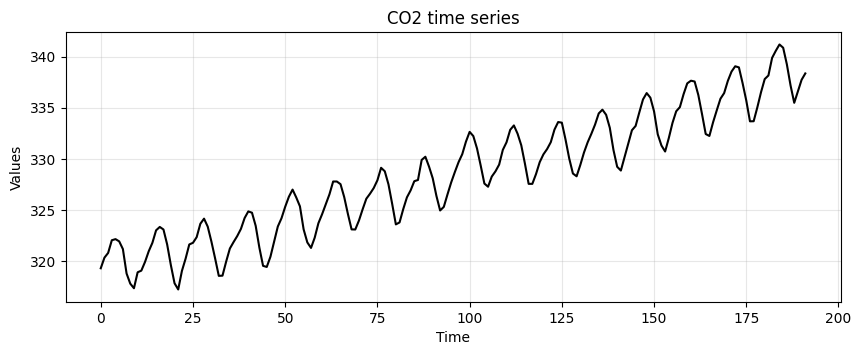

In [7]:
#visualize the time series --> always helpful
co2_time = np.arange(len(co2))
#reshape data into a 1D numpy array (it seems to be some list of shape (192,1))
co2 = np.array(co2).flatten()
run_sequence_plot(co2_time, co2, "CO2 time series")

period, _, _ = fft_analysis(np.array(co2))
print(f"dominant period: {period}")

Now that I know that the dominant period is 12 I can use seasonal decomposition to find out more about seasonality and trend. But also from just the visualization in the plot I can identify some linear trend and some seasonality in the time series. This indicates it is not stationary. 

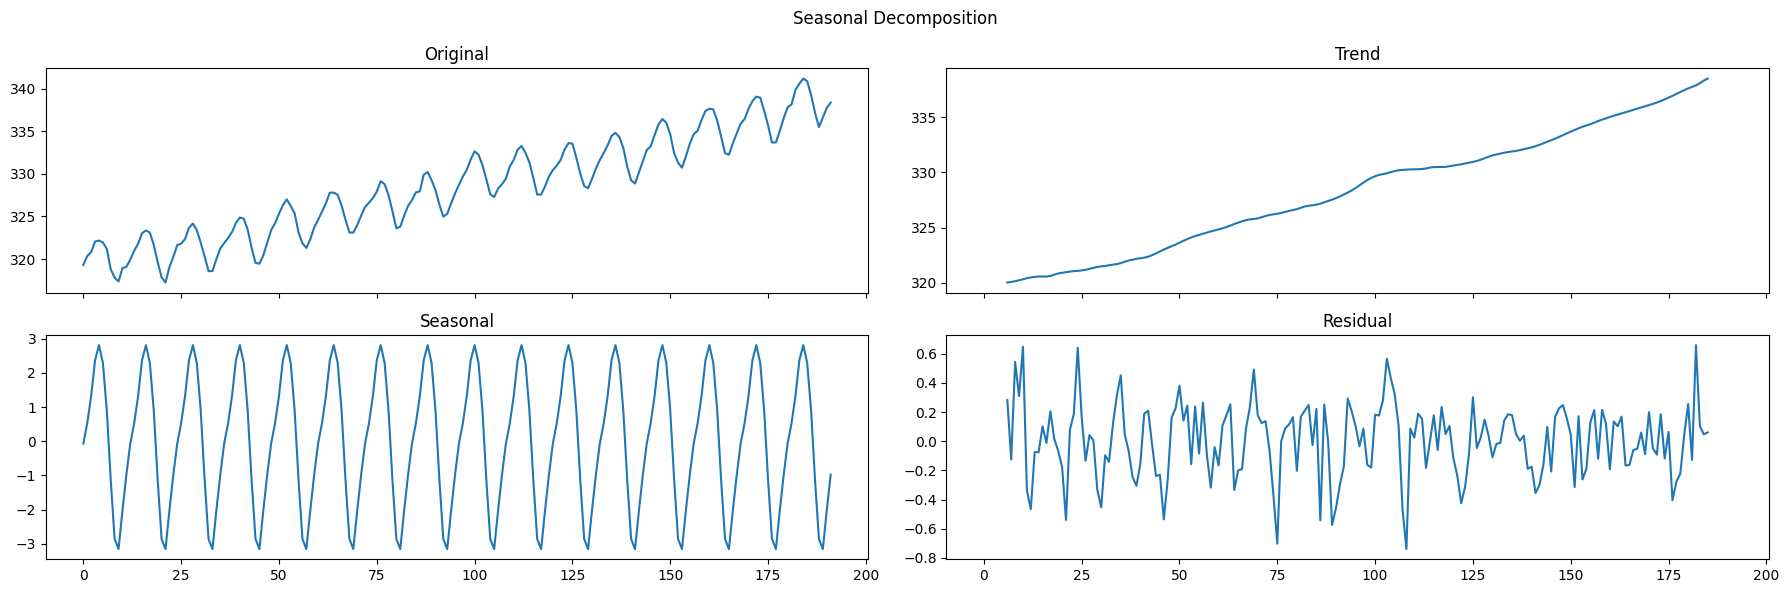

In [8]:
decomposition = seasonal_decompose(co2, "additive", period=12)

fig, axs = plt.subplots(2,2, sharex=True, figsize=(18,6))
axs[0,0].plot(co2)
axs[0,0].set_title('Original')
axs[0,1].plot(decomposition.trend)
axs[0,1].set_title('Trend')
axs[1,0].plot(decomposition.seasonal)
axs[1,0].set_title('Seasonal')
axs[1,1].plot(decomposition.resid)
axs[1,1].set_title('Residual')
plt.suptitle("Seasonal Decomposition")
plt.tight_layout()

The decomposition gives a good estimate for seasonality and also for the trend, even though it is a bit skewed. The residuals don`t have a obvious trend of seasonality anymore and look like noise. 

Now I need to determine stationarity. I already know the time series is not stationary as it has trend and seasonality. So I can first remove those components and then check again afterwards. I will do a Dickey-Fuller test before removing the components and afterwards to have a comparison.

ADF Statistic: 1.27
p-value: 0.996
Critical Values: ['1%: -3.47', '5%: -2.88', '10%: -2.58']

ADF Statistic: -5.05
p-value: 0.000
Critical Values: ['1%: -3.48', '5%: -2.88', '10%: -2.58']



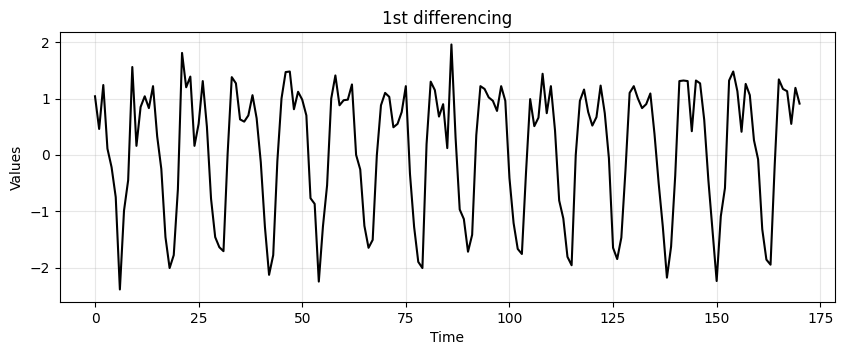

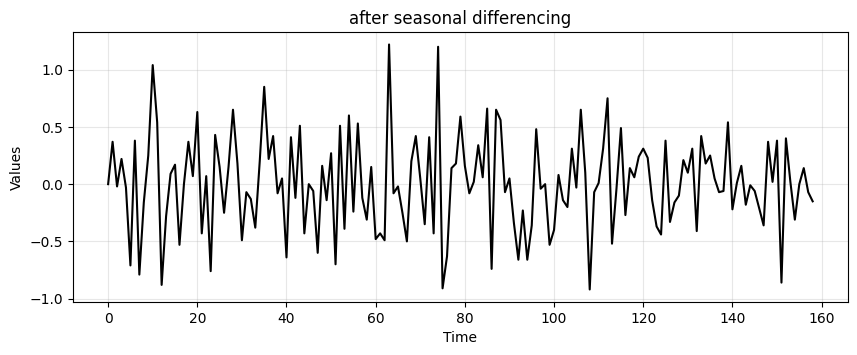

In [9]:
#split the data in test and train data
cut = int(0.9*len(co2))
co2_train = co2[:cut]
co2_test = co2[cut:]
time_train = co2_time[:cut]
time_test = co2_time[cut:]

#adf test on original data
test0 = adfuller(co2, autolag='AIC')
print(f'ADF Statistic: {test0[0]:.2f}')
print(f'p-value: {test0[1]:.3f}')
print(f"Critical Values: {[f'{k}: {r:.2f}' for r,k in zip(test0[4].values(), test0[4].keys())]}\n")

#try differencing to make model stationary
#differencing once
co2_detrended = co2_train[1:] - co2_train[:-1]
#differencing twice
co2_detrended2 = co2_detrended[1:] - co2_detrended[:-1]
#seasonal differencing with period 12: 
#seas. diff. on once-differenced ts
co2_stat = co2_detrended[12:] - co2_detrended[:-12]
#seas. diff. on twice-differenced ts
co2_stat2 = co2_detrended2[12:] - co2_detrended2[:-12]
#both differencing applied twice to ts
co2_stat3 = co2_stat2[12:] - co2_stat2[:-12]

#plots of differencing once (each, linear and seasonal)
run_sequence_plot(time_train[:-1], co2_detrended, "1st differencing")
run_sequence_plot(time_train[:-13], co2_stat, "after seasonal differencing")

#adf test on stationary data
test0 = adfuller(co2_stat, autolag='AIC')
print(f'ADF Statistic: {test0[0]:.2f}')
print(f'p-value: {test0[1]:.3f}')
print(f"Critical Values: {[f'{k}: {r:.2f}' for r,k in zip(test0[4].values(), test0[4].keys())]}\n")

The ADF test indicates a good improvement in seasonality from the original to the differenced time series. This is also supported by the plots where there is still seasonality visible after the first, linear differencing but only noise-like data left after the second, seasonal differencing. 

- Find a set of SARIMAX candidate models by looking at the ACF and PACF.
- Perform a grid search on the model candidates.

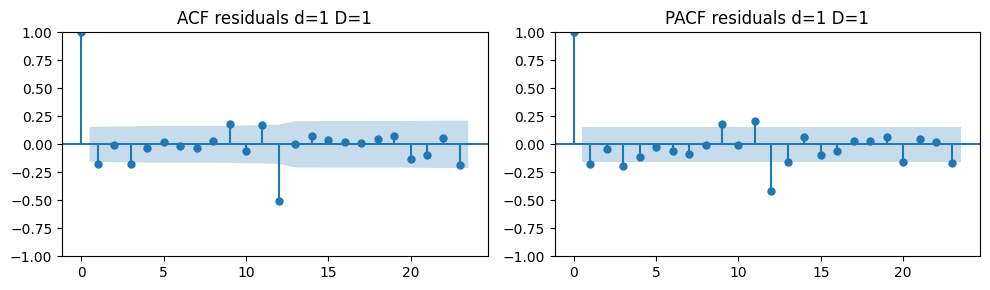

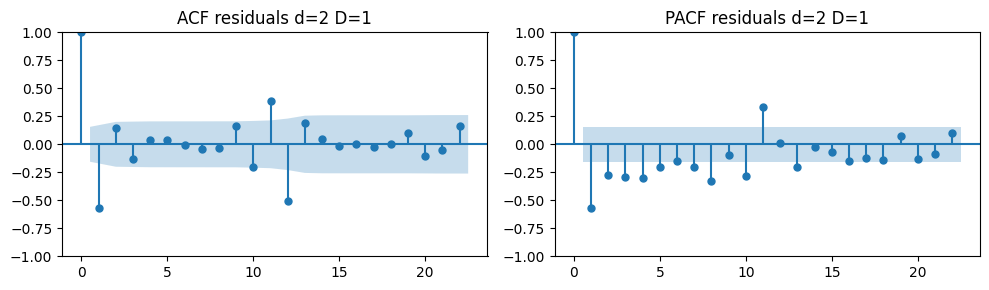

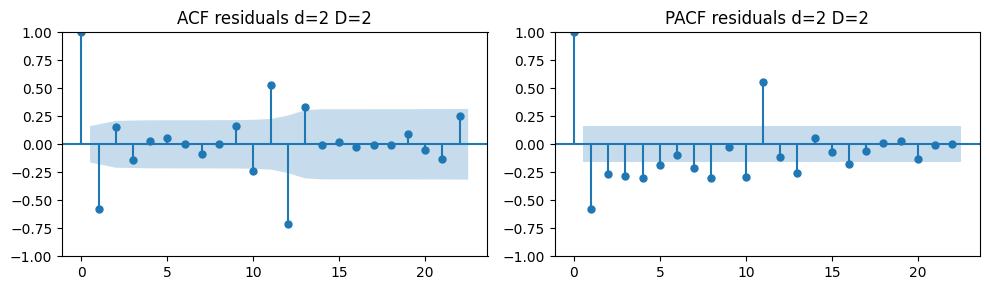

In [10]:
#ACF and PACF of the differenced series
_, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(co2_stat, ax=axes[0], title="ACF residuals d=1 D=1")
plot_pacf(co2_stat, ax=axes[1], title="PACF residuals d=1 D=1")
plt.tight_layout()

#not so helpful yet, more differencing?
_, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(co2_stat2, ax=axes[0], title="ACF residuals d=2 D=1")
plot_pacf(co2_stat2, ax=axes[1], title="PACF residuals d=2 D=1")
plt.tight_layout()

_, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(co2_stat3, ax=axes[0], title="ACF residuals d=2 D=2")
plot_pacf(co2_stat3, ax=axes[1], title="PACF residuals d=2 D=2")
plt.tight_layout()

indicates candidates q = (1,2,3) and p = (1,2,3,4,5)? And I think I need d=2 , but can do either D=1 or D=2 as there is no great obvious improvement between the two. Both can be candidates for the grid search. 

Look at the pacf and acf:

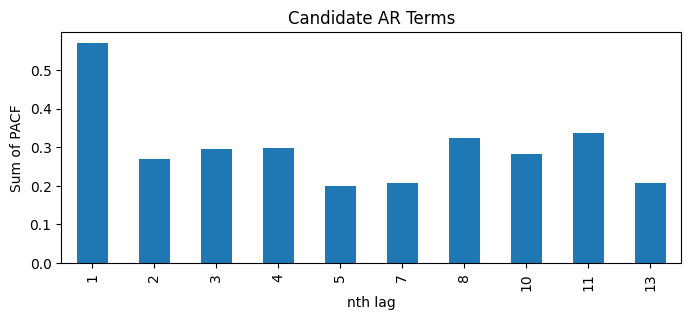

<Axes: title={'center': 'Candidate MA Terms'}, xlabel='nth lag', ylabel='Sum of ACF'>

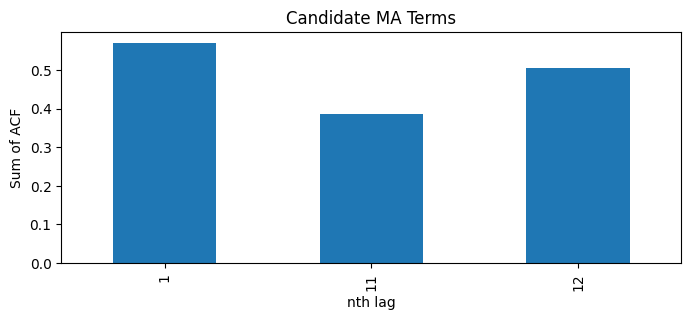

In [11]:
#use function from the lecture
passed_series = pd.DataFrame([co2_stat2]).T
df_sp_p = pd.DataFrame() # create an empty dataframe to store values of significant spikes in PACF plots
for i in passed_series:
    # unpack the results into PACF and their CI
    PACF, PACF_ci = pacf(passed_series[i].dropna(), alpha=0.05, method='ywm')
    # subtract the upper and lower limits of CI by PACF to centre CI at zero
    PACF_ci_ll = PACF_ci[:,0] - PACF
    PACF_ci_ul = PACF_ci[:,1] - PACF
    # find positions of significant spikes representing possible value of p & P
    sp1 = np.where(PACF < PACF_ci_ll)[0]
    sp2 = np.where(PACF > PACF_ci_ul)[0]
    # PACF values of the significant spikes
    sp1_value = abs(PACF[PACF < PACF_ci_ll])
    sp2_value = PACF[PACF > PACF_ci_ul]
    # store values to dataframe
    sp1_series = pd.Series(sp1_value, index=sp1)
    sp2_series = pd.Series(sp2_value, index=sp2)
    df_sp_p = pd.concat((df_sp_p, sp1_series, sp2_series), axis=1)
df_sp_p = df_sp_p.sort_index() # Sort the dataframe by index
# visualize sums of values of significant spikes in PACF plots ordered by lag
df_sp_p.iloc[1:].T.sum().plot(kind='bar', title='Candidate AR Terms', xlabel='nth lag', ylabel='Sum of PACF', figsize=(8,3))
plt.show()
df_sp_q = pd.DataFrame()
for i in passed_series:
    # unpack the results into ACF and their CI
    ACF, ACF_ci = acf(passed_series[i].dropna(), alpha=0.05)
    # subtract the upper and lower limits of CI by ACF to centre CI at zero
    ACF_ci_ll = ACF_ci[:,0] - ACF
    ACF_ci_ul = ACF_ci[:,1] - ACF
    # find positions of significant spikes representing possible value of q & Q
    sp1 = np.where(ACF < ACF_ci_ll)[0]
    sp2 = np.where(ACF > ACF_ci_ul)[0]
    # ACF values of the significant spikes
    sp1_value = abs(ACF[ACF < ACF_ci_ll])
    sp2_value = ACF[ACF > ACF_ci_ul]
    # store values to dataframe
    sp1_series = pd.Series(sp1_value, index=sp1)
    sp2_series = pd.Series(sp2_value, index=sp2)
    df_sp_q = pd.concat((df_sp_q, sp1_series, sp2_series), axis=1)
df_sp_q = df_sp_q.sort_index() # Sort the dataframe by index
# visualize sums of values of significant spikes in ACF plots ordered by lags
df_sp_q.iloc[1:].T.sum().plot(kind='bar', title='Candidate MA Terms', xlabel='nth lag', ylabel='Sum of ACF', figsize=(8,3))

From this I can choose the candidates for P and Q. I looks like P = [1,2,3,4] and Q = [1] might be reasonable.

Do a grid search with the candidates identified here: 

In [12]:
#define candidates
p = [1,2,3,4,5]
d = [2]
q = [1,2,3]
P = [1,2,3,4]
D = [1,2]
Q = [1]
s = [12]

# create all combinations of possible values
pdq = list(product(p, d, q))
PDQm = list(product(P, D, Q, s))

print(f"Number of total combinations: {len(pdq)*len(PDQm)}")

#train model
warnings.simplefilter("ignore")
def SARIMA_grid(endog, order, seasonal_order):

    # create an empty list to store values
    model_info = []
       
    #fit the model
    for i in tqdm(order):
        for j in seasonal_order:
            try:
                model_fit = SARIMAX(endog=endog, order=i, seasonal_order=j).fit(disp=False)
                predict = model_fit.predict()
            
                # calculate evaluation metrics: MAPE, RMSE, AIC & BIC
                MAPE = (abs((endog-predict)[1:])/(endog[1:])).mean()
                MSE = mse(endog[1:], predict[1:])
                AIC = model_fit.aic
                BIC = model_fit.bic
            
                # save order, seasonal order & evaluation metrics
                model_info.append([i, j, MAPE, MSE, AIC, BIC])
            except:
                continue
                
    # create a dataframe to store info of all models
    columns = ["order", "seasonal_order", "MAPE", "MSE", "AIC", "BIC"]
    model_info = pd.DataFrame(data=model_info, columns=columns)
    return model_info

start = time.time()

# fit all combinations into the model
model_info = SARIMA_grid(endog=co2_train, order=pdq, seasonal_order=PDQm)

end = time.time()
print(f'time required: {end - start :.2f}')

Number of total combinations: 120


  0%|          | 0/15 [00:00<?, ?it/s]

time required: 600.32


- Select the best models, based on performance metrics, model complexity, and normality of the residuals.

The best 4 models based on MAPE, MSE, AIC, BIC:

In [13]:
# the best model by each metric
L1 = model_info[model_info.MAPE == model_info.MAPE.min()]
L2 = model_info[model_info.MSE == model_info.MSE.min()]
L3 = model_info[model_info.AIC == model_info.AIC.min()]
L4 = model_info[model_info.BIC == model_info.BIC.min()]

best_models = pd.concat((L1, L2, L3, L4))
best_models

,order,seasonal_order,MAPE,MSE,AIC,BIC
92,"(4, 2, 3)","(3, 1, 1, 12)",0.007845,352.016877,103.502329,140.253469
112,"(5, 2, 3)","(1, 1, 1, 12)",0.007864,352.016291,97.284403,130.972948
112,"(5, 2, 3)","(1, 1, 1, 12)",0.007864,352.016291,97.284403,130.972948
0,"(1, 2, 1)","(1, 1, 1, 12)",0.007900,352.026563,104.030462,119.343437


Here the same model appears twice actually (nr 112), for performance and complexity. That`s a strong candidate. 

Looking at normality of the residuals, plotting diagnostic plots:

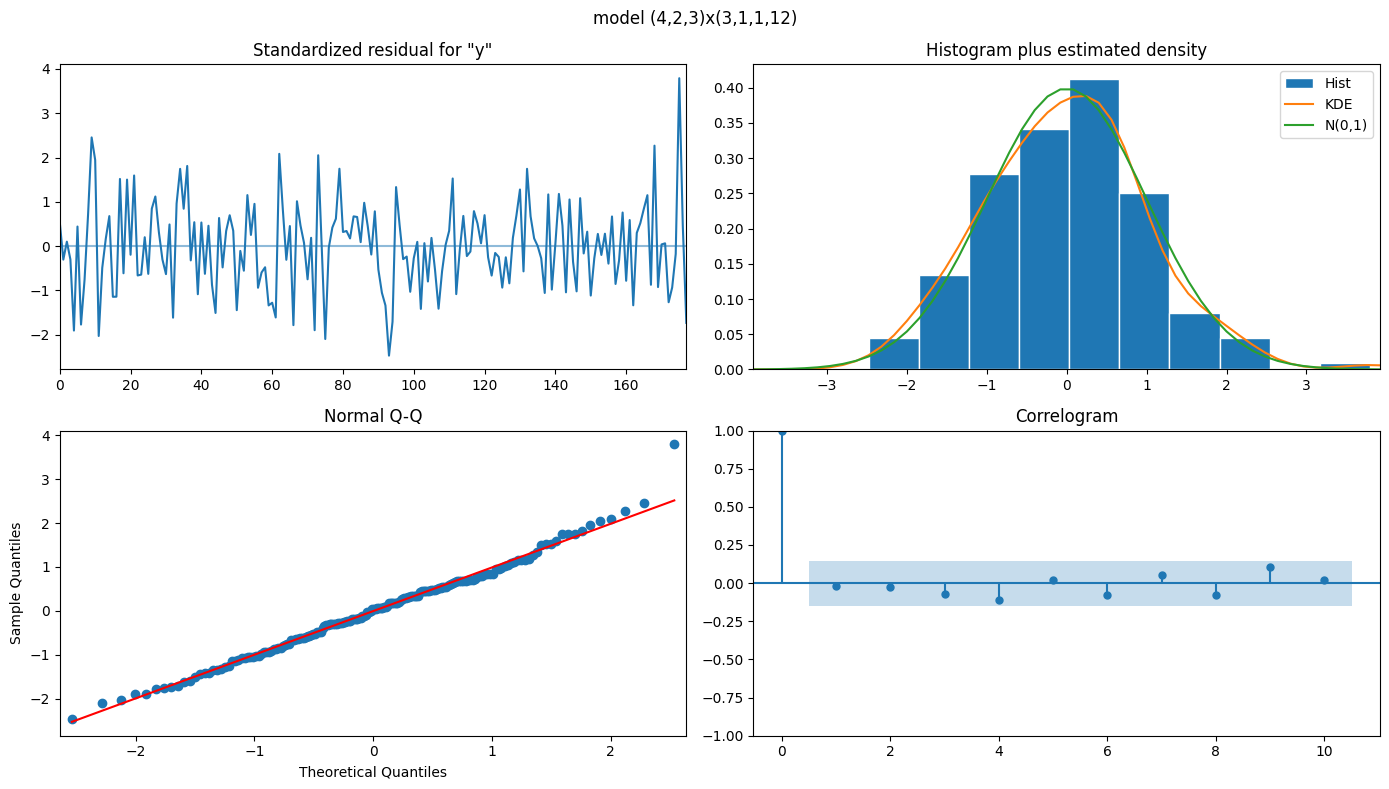

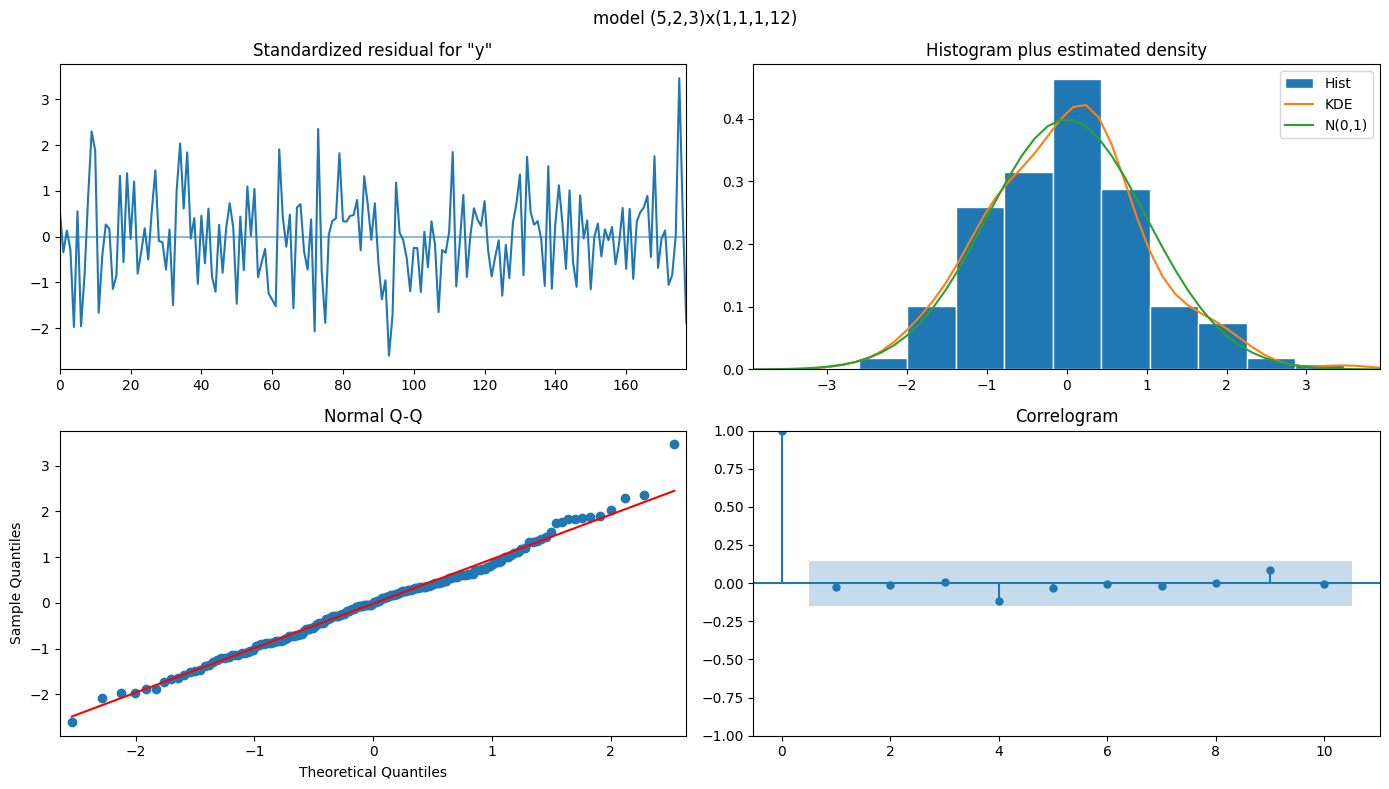

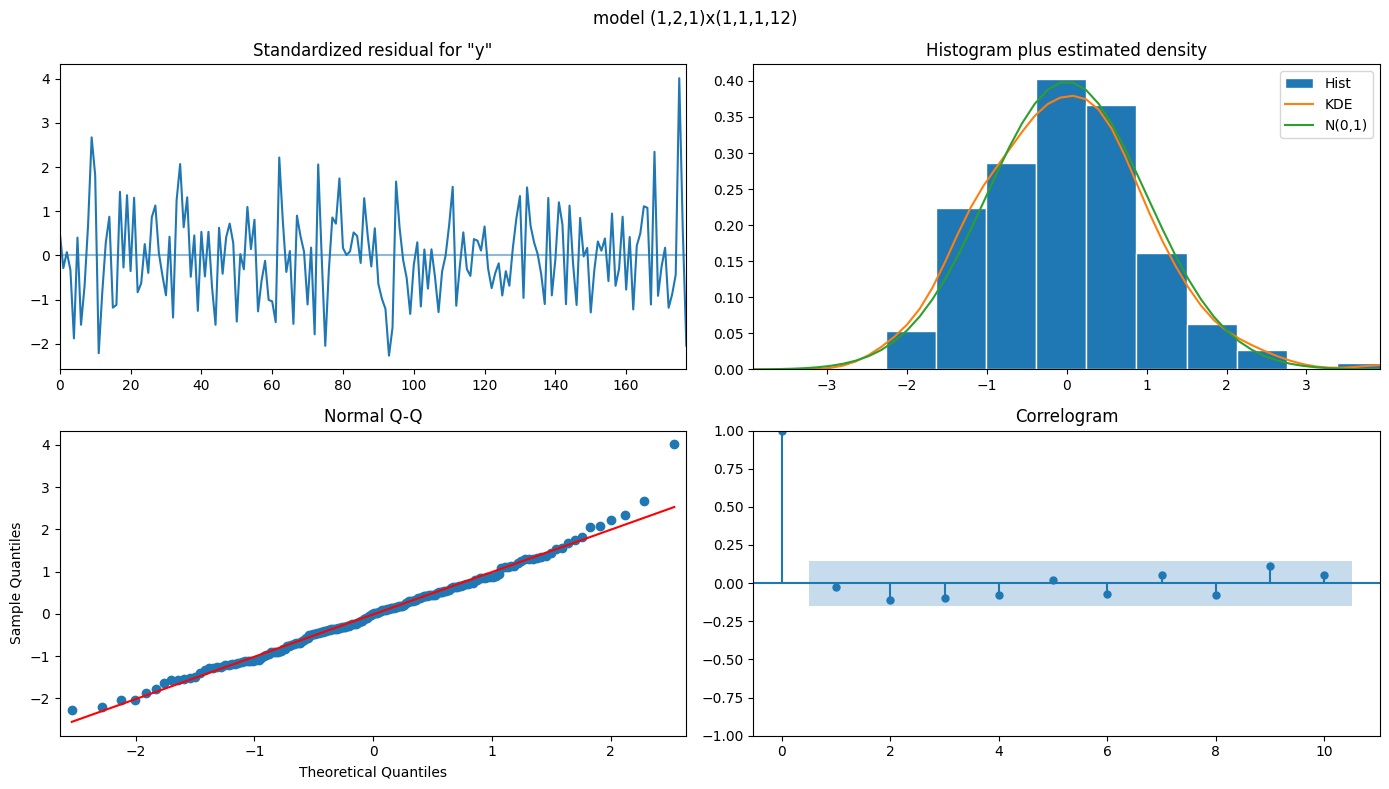

In [14]:
#compute predictions based on the models here and then see if the residuals are normally distributed
#use sarimax
model1 = ss.tsa.statespace.sarimax.SARIMAX(co2, 
                                order=(4,2,3), 
                                seasonal_order=(3,1,1,12), 
                                trend='c').fit(disp=False)
model2 = ss.tsa.statespace.sarimax.SARIMAX(co2, 
                                order=(5,2,3), 
                                seasonal_order=(1,1,1,12), 
                                trend='c').fit(disp=False)
model3 = ss.tsa.statespace.sarimax.SARIMAX(co2, 
                                order=(1,2,1), 
                                seasonal_order=(1,1,1,12), 
                                trend='c').fit(disp=False)


model1.plot_diagnostics(figsize=(14, 8))
plt.suptitle("model (4,2,3)x(3,1,1,12)")
plt.tight_layout()
plt.show()
model2.plot_diagnostics(figsize=(14, 8))
plt.suptitle("model (5,2,3)x(1,1,1,12)")
plt.tight_layout()
plt.show()
model3.plot_diagnostics(figsize=(14, 8))
plt.suptitle("model (1,2,1)x(1,1,1,12)")
plt.tight_layout()
plt.show()


Just from looking at the normality diagnostics plots there is no real outliner to identifier, not in a good or bad way. Maybe the second model looks like it does the worst job judging by the histogram, but that`s actually the model that has both top performance and low complexity. 

- Compare the best model you found with the one from autoarima.


In [15]:
#autoarima
model_auto = pm.auto_arima(co2_train, 
                      start_p=0, start_q=0,
                      test='adf',       # Use adftest to find optimal 'd'
                      max_p=5, max_q=3, # Maximum p and q
                      m=12,             # Seasonality
                      start_P=0, start_Q=0,
                      max_P=4, max_Q=1, # Maximum p and q
                      seasonal=True,    # Seasonal ARIMA
                      d=2,           # Let model determine 'd'
                      D=None,              # Seasonal difference
                      trace=True,       # Print status on the fits
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)    # Stepwise search to find the best model

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,1,0)[12]             : AIC=304.935, Time=0.01 sec
 ARIMA(1,2,0)(1,1,0)[12]             : AIC=192.247, Time=0.18 sec
 ARIMA(0,2,1)(0,1,1)[12]             : AIC=inf, Time=0.41 sec
 ARIMA(1,2,0)(0,1,0)[12]             : AIC=245.045, Time=0.03 sec
 ARIMA(1,2,0)(2,1,0)[12]             : AIC=190.184, Time=0.28 sec
 ARIMA(1,2,0)(3,1,0)[12]             : AIC=187.731, Time=0.60 sec
 ARIMA(1,2,0)(4,1,0)[12]             : AIC=183.702, Time=1.30 sec
 ARIMA(1,2,0)(4,1,1)[12]             : AIC=inf, Time=6.90 sec
 ARIMA(1,2,0)(3,1,1)[12]             : AIC=inf, Time=2.65 sec
 ARIMA(0,2,0)(4,1,0)[12]             : AIC=252.047, Time=0.80 sec
 ARIMA(2,2,0)(4,1,0)[12]             : AIC=168.234, Time=1.37 sec
 ARIMA(2,2,0)(3,1,0)[12]             : AIC=170.651, Time=0.76 sec
 ARIMA(2,2,0)(4,1,1)[12]             : AIC=169.966, Time=3.29 sec
 ARIMA(2,2,0)(3,1,1)[12]             : AIC=inf, Time=2.41 sec
 ARIMA(3,2,0)(4,1,0)[12]             : AIC=158.67

In [16]:
print(model_auto.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  172
Model:             SARIMAX(5, 2, 0)x(4, 1, 0, 12)   Log Likelihood                 -61.424
Date:                            Thu, 26 Mar 2026   AIC                            142.848
Time:                                    17:59:27   BIC                            173.474
Sample:                                         0   HQIC                           155.286
                                            - 172                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0303      0.078    -13.199      0.000      -1.183      -0.877
ar.L2         -0.8030      0.103   

AutoARIMA doesn't settle on the same model parameters as the grid search method, and the AIC and BIC are higher for the AutoARIMA model(in my run 145 compared to 119, 131 and 140 for the AIC for example). This means the better model is the one found by SARIMAX grid search. Here is still also the diagnostics of the autoARIMA model, just for comparison:

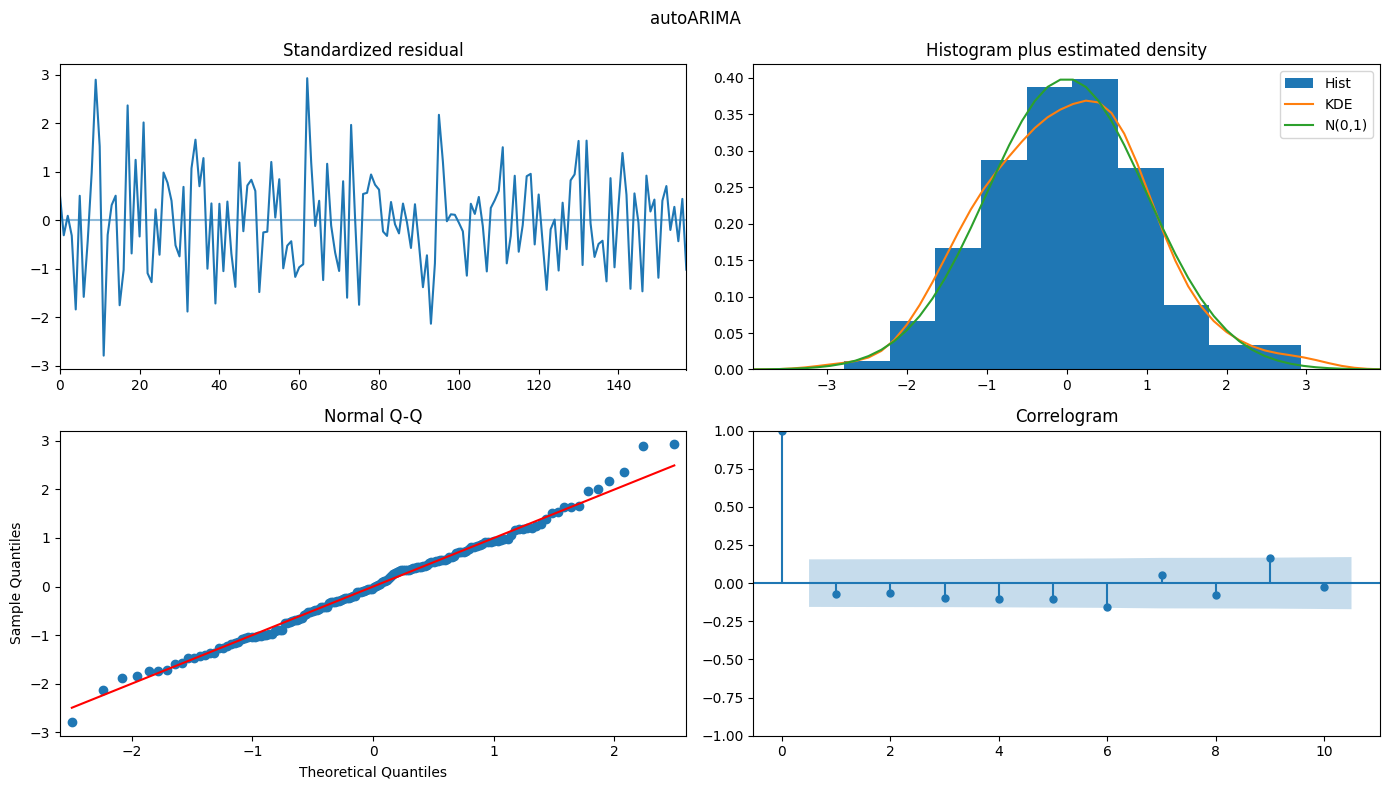

In [17]:
model_auto.plot_diagnostics(figsize=(14, 8))
plt.suptitle("autoARIMA")
plt.tight_layout()

## Chapter 06

### Exercise 

- Download and plot the historical closing prices of Tesla (``TSLA``) and Equinor (``EQNR``) for the years ``2019-12-31``- ``2022-12-31``.
- For each time series:
    - Test if the time series look stationary.

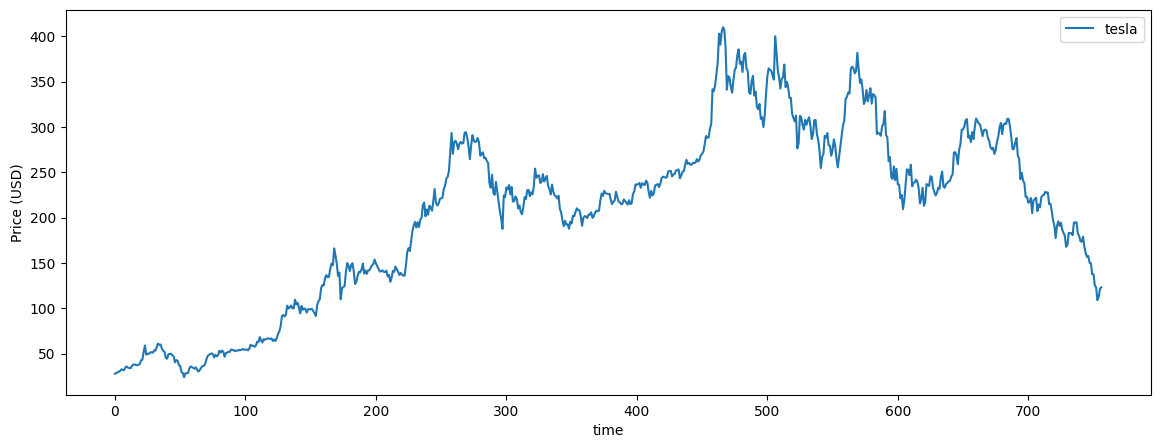

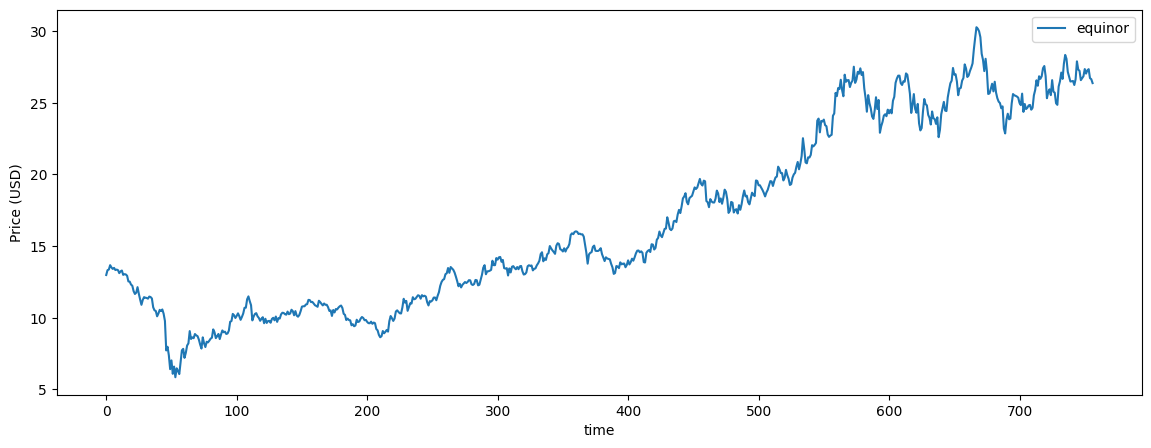

In [18]:
def get_data(tickerSymbol, start, end):

    # Get data on the ticker
    tickerData = yf.Ticker(tickerSymbol)

    # Get the historical prices for this ticker
    tickerDf = tickerData.history( start=start, end=end)
    
    return tickerDf
    
data_t = get_data('TSLA', start='2019-12-31', end='2022-12-31')
data_e = get_data('EQNR', start='2019-12-31', end='2022-12-31')

tesla = np.array(data_t["Close"])
equinor = np.array(data_e["Close"])

plt.figure(figsize=(14, 5))
plt.plot(tesla, label="tesla")
plt.xlabel("time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(equinor, label="equinor")
plt.xlabel("time")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


In [19]:
#test stationarity, use ADF test and chunks analysis
#tesla
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(tesla, regression = "ct")
print(f"ADF {adf:.2f}")
print(f"p value: {pvalue:.2f}")

print(tesla.shape)
chunks_tesla = np.split(tesla[:-1], indices_or_sections=21)

print("{}\t | {}\t\t | {}".format("Chunk", "Mean", "Variance"))
print("-" * 35)
for i, chunk in enumerate(chunks_tesla, 1):
    print("{:2}\t | {:.5}\t | {:.5}".format(i, np.mean(chunk), np.var(chunk)))


ADF -0.93
p value: 0.95
(757,)
Chunk	 | Mean		 | Variance
-----------------------------------
 1	 | 42.43	 | 105.85
 2	 | 38.926	 | 66.805
 3	 | 52.76	 | 10.866
 4	 | 81.297	 | 291.92
 5	 | 122.59	 | 451.82
 6	 | 141.35	 | 34.355
 7	 | 187.8	 | 930.31
 8	 | 272.59	 | 283.9
 9	 | 223.87	 | 175.58
10	 | 216.34	 | 381.56
11	 | 215.02	 | 82.087
12	 | 238.2	 | 80.995
13	 | 297.47	 | 2832.6
14	 | 349.78	 | 508.63
15	 | 323.73	 | 908.48
16	 | 310.28	 | 1474.2
17	 | 276.23	 | 1624.2
18	 | 239.58	 | 218.79
19	 | 293.35	 | 110.17
20	 | 239.6	 | 999.74
21	 | 167.85	 | 629.84


There are large changes in mean (between 38 and over 300) and even larger in variance (between 10 and 2832). The time series is not stationary. 

In [20]:
chunks_equinor = np.split(equinor[:-1], indices_or_sections=21)

print("{}\t | {}\t\t | {}".format("Chunk", "Mean", "Variance"))
print("-" * 35)
for i, chunk in enumerate(chunks_equinor, 1):
    print("{:2}\t | {:.5}\t | {:.5}".format(i, np.mean(chunk), np.var(chunk)))

Chunk	 | Mean		 | Variance
-----------------------------------
 1	 | 12.425	 | 0.74934
 2	 | 8.3547	 | 2.2857
 3	 | 9.187	 | 0.65503
 4	 | 10.178	 | 0.19527
 5	 | 10.731	 | 0.1035
 6	 | 9.626	 | 0.23934
 7	 | 10.86	 | 0.39454
 8	 | 12.531	 | 0.2836
 9	 | 13.51	 | 0.12144
10	 | 14.544	 | 0.50484
11	 | 14.509	 | 0.6903
12	 | 14.799	 | 0.80387
13	 | 18.13	 | 0.94707
14	 | 18.34	 | 0.38727
15	 | 20.069	 | 0.76436
16	 | 24.574	 | 3.162
17	 | 25.289	 | 1.5316
18	 | 24.656	 | 1.1874
19	 | 27.234	 | 1.8309
20	 | 25.164	 | 1.146
21	 | 26.642	 | 0.63873


There is much less variability in mean and variance. This time series might be stationary although it does look like it has a trend. I can do a ADF test as a backup test. 

In [21]:
#ADF test on equinor ts
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(equinor, regression = "c")
print(f"ADF {adf:.2f}")
print(f"p value: {pvalue:.2f}")

adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(equinor, regression = "ct")
print(f"ADF {adf:.2f}")
print(f"p value: {pvalue:.2f}")


ADF -0.44
p value: 0.90
ADF -3.60
p value: 0.03


The test passes when taking the trend into account but not without it. So the time series is not stationary per se, but after removing the trend it will probably be. 

- Compute the Hurst coefficient for both time series.
- Which stock would you like to invest into? Motivate your answer based on the tests and the value of $H$.

In [22]:
#compute Hurst coeff
def hurst(ts):  
    # Create the range of lag values
    lags = range(2, 100)
    # Calculate the array of the variances of the lagged differences
    tau = [np.var(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    # Use a linear fit to estimate the Hurst exponent
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    # Return the Hurst exponent from the polyfit output
    return poly[0]/2.0

hurst_tesla = hurst(tesla)
hurst_equinor = hurst(equinor)

print(f"hurst coefficient tesla: {hurst_tesla:.2f}")
print(f"hurst coefficient equinor: {hurst_equinor:.2f}")

hurst coefficient tesla: 0.46
hurst coefficient equinor: 0.33


Both coefficients are below 0.5, so they don't indicate a strong trend. Tesla with a coefficient of 0.46 is closer to a random walk or even trending, while equinor is more clearly < 0.5 which means mean reverting. This seems counterintuitive as when looking at the plots it seems like equinor is trending.

According to the hurst coefficients equinor is the safer choice to invest in longterm as it probably will revert to its mean after a while if not something out of the ordinary happens. But as it is above the mean currently this also means it will probably drop to get back to the mean which means losing money. But when Tesla has an upward trend, and this seems to be the case here, it might be a good investment choice as it can be expected to continue rising. So this might be the better choice here to invest in and hope to earn money on it. 

- Simulate the stock prices using GBM.
- Which simulation seems to be more reliable? The one for Tesla or Equinor? 
- To motivate your answer: 
    1. compute the simulation at least 100 times.
    2. Compute the MSE between the true stock prices and the simulated ones.
    3. Compare the expected value of the MAPE for the two stocks.

GBM: $S(t) = S_0 \exp\left((\mu - \frac{1}{2} \sigma^2)t + \sigma W(t)\right)$

MSE tesla: 2562
MSE equinor: 45
MAPE tesla: 49.28 %
MAPE equinor: 68.49 %


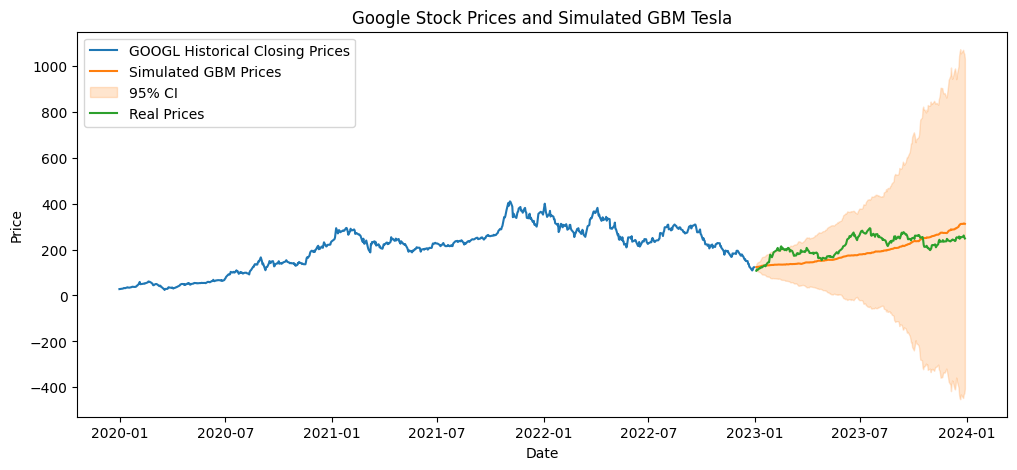

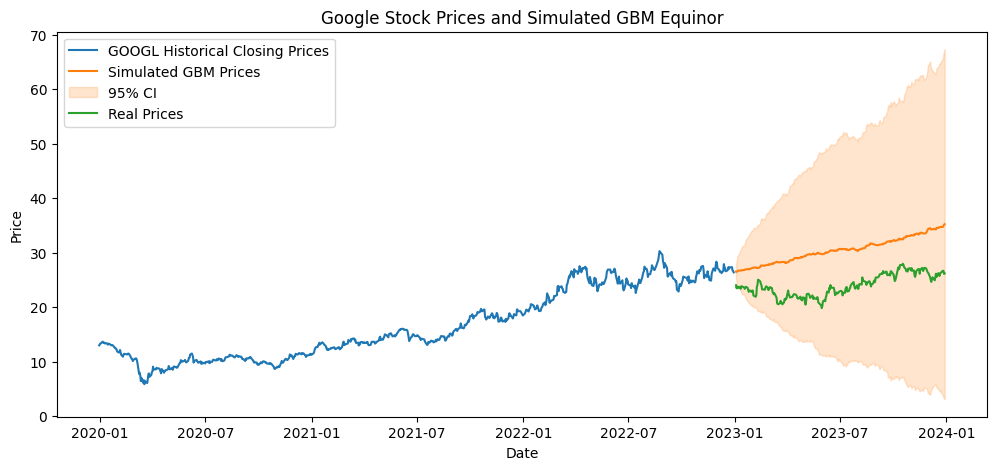

In [23]:
##set up parameters for GBM
#identical for both ts:
T = 1  #time period in years (for the prediction)
N = int(len(tesla)/3)-2 #number of timesteps
dt = T/N #time step in years
t  = np.linspace(0, T, N)
#tesla
S0_tesla = tesla[-1] #last point in the data
mu_tesla = data_t["Close"].pct_change().mean() * N #annualized mean
sigma_tesla = data_t["Close"].pct_change().std() * np.sqrt(N) #annualized std
#equinor
S0_equinor = equinor[-1]
mu_equinor = data_e["Close"].pct_change().mean() * N
sigma_equinor= data_e["Close"].pct_change().std() * np.sqrt(N)

#calculate GBM for 100 paths
def GBM_simulation(mu, sigma, time_step, S0):
    paths = []
    for _ in range(100):
        W = np.cumsum(np.random.standard_normal(size=N))*np.sqrt(dt)
        X = (mu - 0.5 * sigma**2) * time_step + sigma * W
        paths.append(S0 * np.exp(X))
    path_mean = np.array(paths).mean(axis=0)
    path_std = np.array(paths).std(axis=0)
    return path_mean, path_std

GBM_tesla_m, GBM_tesla_std = GBM_simulation(mu_tesla, sigma_tesla, t, S0_tesla)
GBM_equinor_m, GBM_equinor_std = GBM_simulation(mu_equinor, sigma_equinor, t, S0_equinor)

#download real data for the following year to compare to simulation
tesla_compare = get_data('TSLA', start='2022-12-31', end='2023-12-31')
equinor_compare = get_data('EQNR', start='2022-12-31', end='2023-12-31')

#plot of the simulated GBM and the real stock prices
plt.figure(figsize=(12, 5))
plt.plot(data_t["Close"].index, tesla, label='GOOGL Historical Closing Prices')
plt.plot(tesla_compare["Close"].index, GBM_tesla_m, label='Simulated GBM Prices')
plt.fill_between(tesla_compare["Close"].index, GBM_tesla_m-1.96*GBM_tesla_std, GBM_tesla_m+1.96*GBM_tesla_std, color='tab:orange', alpha=0.2, label='95% CI')
plt.plot(tesla_compare['Close'], label='Real Prices')
plt.legend(loc='upper left')
plt.title('Google Stock Prices and Simulated GBM Tesla')
plt.xlabel('Date')
plt.ylabel('Price')

plt.figure(figsize=(12, 5))
plt.plot(data_e["Close"].index, equinor, label='GOOGL Historical Closing Prices')
plt.plot(equinor_compare["Close"].index, GBM_equinor_m, label='Simulated GBM Prices')
plt.fill_between(tesla_compare["Close"].index, GBM_equinor_m-1.96*GBM_equinor_std, GBM_equinor_m+1.96*GBM_equinor_std, color='tab:orange', alpha=0.2, label='95% CI')
plt.plot(equinor_compare['Close'], label='Real Prices')
plt.legend(loc='upper left')
plt.title('Google Stock Prices and Simulated GBM Equinor')
plt.xlabel('Date')
plt.ylabel('Price')

#calculate MSE between predicted and real
tesla_mse = mse(GBM_tesla_m, tesla_compare["Close"], axis=0)
equinor_mse = mse(GBM_equinor_m, equinor_compare["Close"], axis=0)

print(f"MSE tesla: {tesla_mse:.0f}")
print(f"MSE equinor: {equinor_mse:.0f}")

#calculate expected MAPE for both stocks
tesla_mape = np.sum( (np.abs((tesla_compare["Close"] - GBM_tesla_m)/tesla_compare["Close"])) ).mean()
equinor_mape = np.sum( (np.abs((equinor_compare["Close"] - GBM_equinor_m)/equinor_compare["Close"])) ).mean()

print(f"MAPE tesla: {tesla_mape:.2f} %")
print(f"MAPE equinor: {equinor_mape:.2f} %")

As the two stocks are in quite different price ranges MAPE might be more representative as it shows the relative error and not the absolute error. MSE is mostly lower for the Equinor stocks but MAPE is lower for the equinor stocks. This would make Tesla the more reliable prediction here. 

But in absolute values the equinor prices have a much smaller range of variablity, and the range of the confidence intervall for tesla is about 700 while it is only about 70 for equinor. This would make the potential loss much smaller for equinor.  

## Chapter 07

### Exercise #1
This exercise refers to [Example 1](#example-1-static-one-dimensional-data).
1. Choose a value for the estimated model variance `Q_est` that is larger than estimated measurement variance `R_est`.
2. Repeat the analysis of Example 1 for this new value. 
3. Does the KF estimate converge?
4. Why the estimates changed? Do they look more noisy than before? Why?

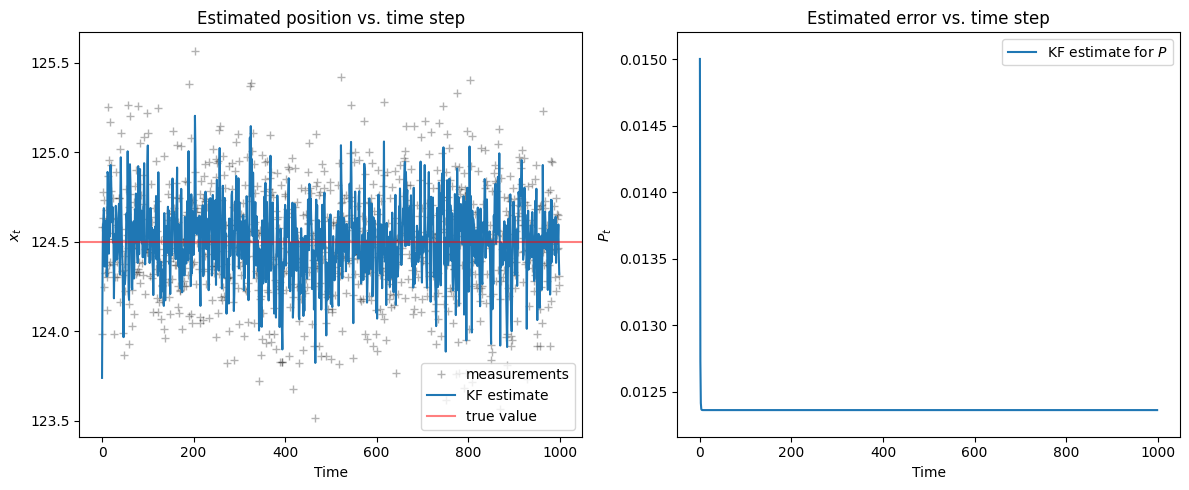

In [24]:
#from the lecture: Kalman filter algorithm 1D
def kalman_1d(x, P, measurement, R_est, Q_est):
    
    # Prediction
    x_pred = x
    P_pred = P + Q_est
    # Update
    K = P_pred / (P_pred + R_est)
    x_est = x_pred + K * (measurement - x_pred)
    P_est = (1 - K) * P_pred

    return x_est, P_est

#from the lecture: plotting functions
def plot_1d_comparison(measurements_made, estimate, true_value, axis):
    axis.plot(measurements_made,'k+',label='measurements',alpha=0.3)
    axis.plot(estimate,'-',label='KF estimate')
    if not isinstance(true_value, (list, tuple, np.ndarray)):
        # plot line for a constant value
        axis.axhline(true_value,color='r',label='true value', alpha=0.5) 
    else:
        # for a list, tuple or array, plot the points
        axis.plot(true_value,color='r',label='true value', alpha=0.5)
    axis.legend(loc = 'lower right')
    axis.set_title('Estimated position vs. time step')
    axis.set_xlabel('Time')
    axis.set_ylabel('$x_t$')
    
def plot_1d_error(estimated_error, lower_limit, upper_limit, axis):
    # lower_limit and upper_limit are the lower and upper limits of the vertical axis 
    axis.plot(estimated_error, label='KF estimate for $P$')
    axis.legend(loc = 'upper right')
    axis.set_title('Estimated error vs. time step')
    axis.set_xlabel('Time')
    axis.set_ylabel('$P_t$')
    plt.setp(axis,'ylim',[lower_limit, upper_limit])

#example 1 generated data
mu = 124.5 # Actual position
R = 0.1    # Actual standard deviation of actual measurements (R)
n_measurements = 1000 
Z = np.random.normal(mu, np.sqrt(R), size=n_measurements)

# Estimated covariances, such that Q_est > R_est
Q_est = 2.002e-2 
R_est = 2e-2 
# initial guesses 
x = 123 # Use an integer
P = 0.04 # error covariance P

KF_estimate=[]  
KF_error=[] 
for z in Z:
    x, P = kalman_1d(x, P, z, R_est, Q_est)
    KF_estimate.append(x)
    KF_error.append(P)

#plot the results
fig, axes = plt.subplots(1,2, figsize=(12, 5))
plot_1d_comparison(Z, KF_estimate, mu, axes[0])
plot_1d_error(KF_error, np.min(KF_error)-0.0002, np.max(KF_error)+0.0002,axes[1] )
plt.tight_layout()

3. It seems like the higher Q, the worse the model performs and the less the error converges. For Q = 1e-1 for example the model almost just plots the noisy measurements Z without any improvement. For a Q that is just slighly larger, for example Q = 2.002e-2 the estimates still look very noisy but with slightly less amplitude and the error converges a bit better. 

4. Q is the process noise covariance and R is the measurement noise covariance. If we say that the process noise covariance is higher than the measurement one, this means that there is more noise in the modelled process than the measurement, so it kind of makes sense that the estimate relies more on the measurement and tries to follow that. 

### Exercise #2

This exercise refers to [Example 2](#example-2-dynamic-one-dimensional-data). 

In the case we examined above, the KF estimate was close to the measurements and both were different from the true value.
Change the parameters of the algorithm until you find some combinations that achieve the following:

1. Measurements, KF estimate and true value are all close.
2. Measurements, KF estimate and true value are all noticeably different.
3. The measurements are close to the true value, but the KF estimate is different.

Discuss your findings.

This is the code for example 2, unchanged:

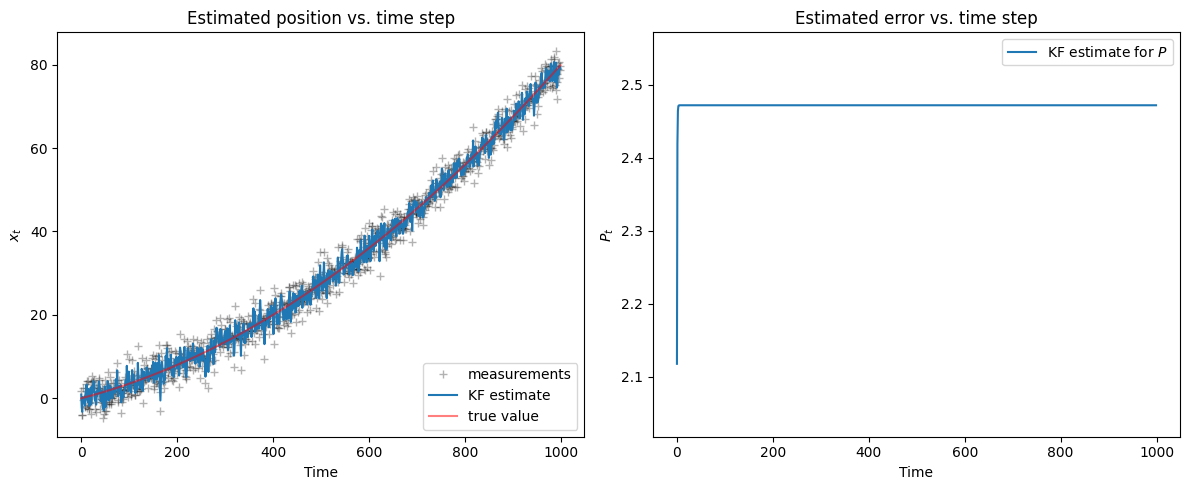

In [25]:
##example 02 generated data:
# initial parameters
v0 = 0.3
a = 5e-3
x0 = 0.0     
R = 8.0
delta_t = 0.1

# generate true positions
n_measurements = 1000
Xt = np.zeros(n_measurements) 
for t in range(0, n_measurements):
    Xt[t]= x0 + v0*t*delta_t + a*t**2*delta_t**2

# generate noisy measurements
Zx = np.zeros(n_measurements)
for t in range(0, n_measurements):
    Zx[t]= Xt[t] + np.random.normal(0, np.sqrt(R), 1)[0]

# Initial guesses and estimates from kalman filter
x = 0 
P = 0.5
Q_est = 4 
R_est = 4
KF_estimate = [] 
KF_error = []     

# Kalman filter
for z in Zx:
    x, P = kalman_1d(x, P, z, R_est, Q_est)
    KF_estimate.append(x)
    KF_error.append(P)

fig, axes = plt.subplots(1,2, figsize=(12, 5))
plot_1d_comparison(Zx, KF_estimate, Xt, axes[0])
plot_1d_error(KF_error, min(KF_error)-0.1, max(KF_error)+0.1, axes[1])
plt.tight_layout()

1. 

I can use a smaller value of R in the initial paramters to achieve measurements that are closer to the true value. Then I can change the estimate of Q "Q_est" to a smaller value, such that it is smaller than "R_est" to have the KF estimate closer to the true value. Also choosing Q_est and R_est some orders of magnitude smaller decreases the estimated error.

 Changing the initial guesses doesn't seem to have a big impact on the algorithm as the values get updated really quick with new predictions and the estimate starts to oscillate around the true value. So the parameters that seem to have the most effect are r, Q_est and R_est.

Result all three close:

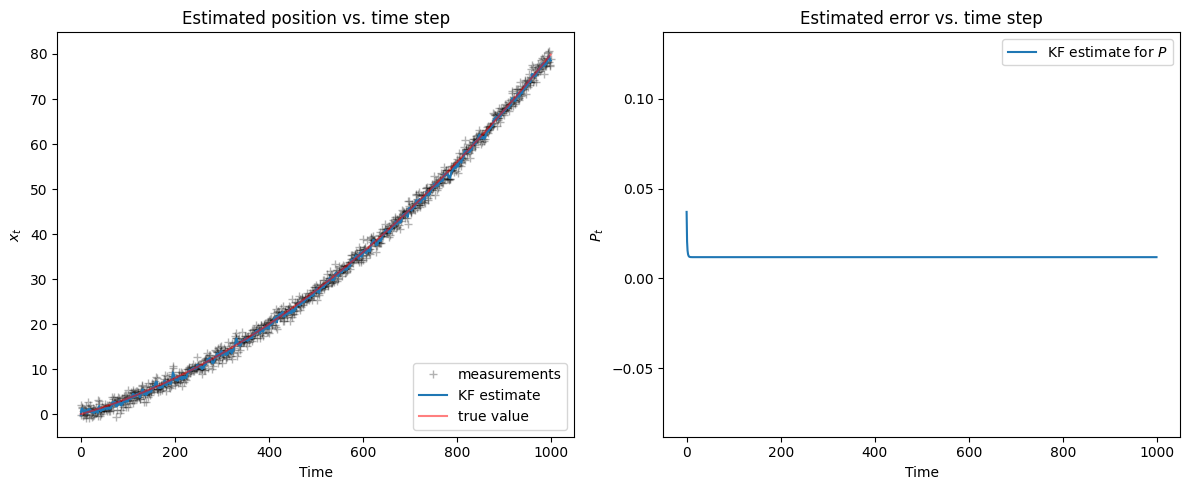

In [26]:
#change some parameters
R = 1.0
Q_est = 0.5e-2
R_est = 4e-2
# generate new noisy measurements
Zx = np.zeros(n_measurements)
for t in range(0, n_measurements):
    Zx[t]= Xt[t] + np.random.normal(0, np.sqrt(R), 1)[0]
#reset lists and initial guesses
x = 0 
P = 0.5
KF_estimate = [] 
KF_error = []

# apply Kalman filter
for z in Zx:
    x, P = kalman_1d(x, P, z, R_est, Q_est)
    KF_estimate.append(x)
    KF_error.append(P)

fig, axes = plt.subplots(1,2, figsize=(12, 5))
plot_1d_comparison(Zx, KF_estimate, Xt, axes[0])
plot_1d_error(KF_error, min(KF_error)-0.1, max(KF_error)+0.1, axes[1])
plt.tight_layout()

2. Higher noise in the measurements is achieved by adding higher R to the generated data. This makes the measurements noticably different from the true value. Changing R_est to a higher value (here 8) and Q_est to a value smaller than that (here 0.5) makes the KF estimate lean towards the true value, but doesn`t quite reach it. Also as the noise has some significant value, not something of the order of e-4 or something but 0.5 and 8, the error doesn't converge to 0 but rather to some value, around 1.5 here. 
I hope this counts as all "noticably different".

Result all different:

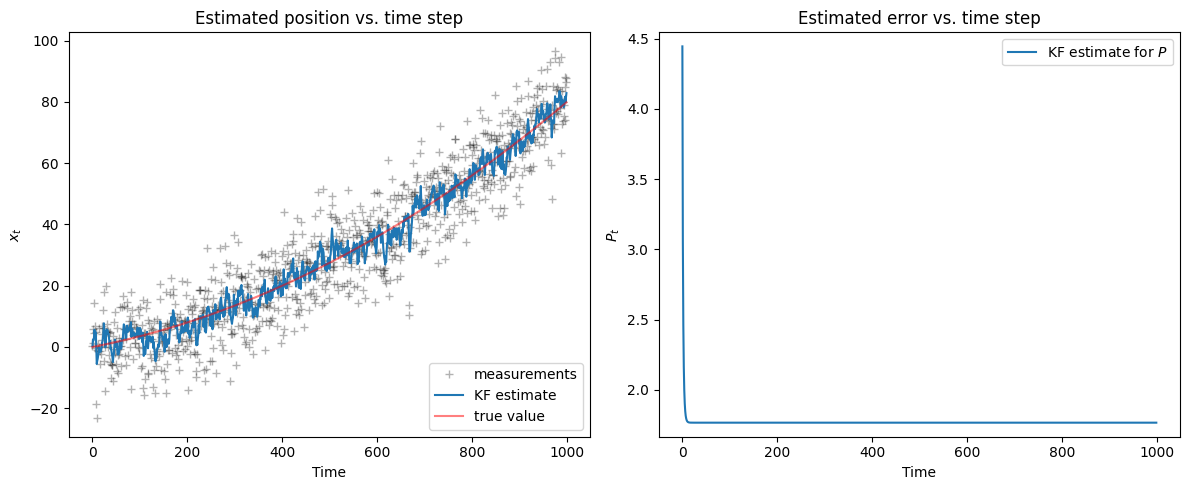

In [27]:
#change some parameters again
R = 80.0
Q_est = 0.5 
R_est = 8
# generate new noisy measurements
Zx = np.zeros(n_measurements)
for t in range(0, n_measurements):
    Zx[t]= Xt[t] + np.random.normal(0, np.sqrt(R), 1)[0]
#reset lists and initial guesses
x = 0 
P = 9.5
KF_estimate = [] 
KF_error = []

# apply Kalman filter
for z in Zx:
    x, P = kalman_1d(x, P, z, R_est, Q_est)
    KF_estimate.append(x)
    KF_error.append(P)

fig, axes = plt.subplots(1,2, figsize=(12, 5))
plot_1d_comparison(Zx, KF_estimate, Xt, axes[0])
plot_1d_error(KF_error, min(KF_error)-0.1, max(KF_error)+0.1, axes[1])
plt.tight_layout()

3. To have the measurements close to true value I need to have low noise the in measurement (R) again. To have a really bad Kalman estimate I now chose horrible starting conditions, x = 100 instead of 0 like in the generated data and a starting error P = 4000. Then the measurement noise covariance R_est must be chosen very high so that the model doesn't rely on the measurements too much, which are close to the true value here. Then I chose a very low process noise covariance so that the estimate relies much on the model, which I chose a very bad starting point for. 
All values here are chosen arbitrarily but intentionally ridiculously far away from reasonable estimates.

Result for measurements close to true value but KF estimate different:

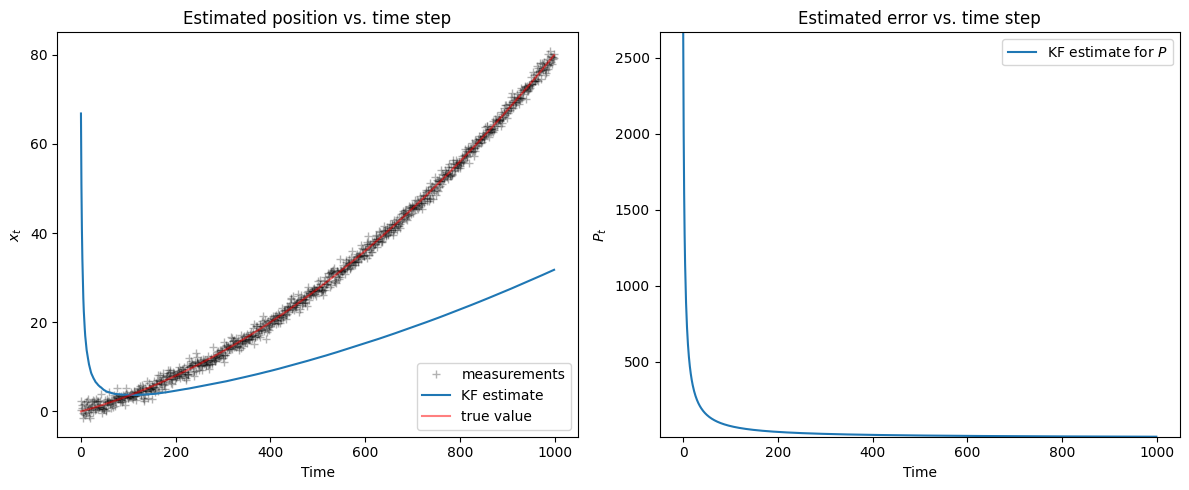

In [28]:
#change some parameters again
R = 1.0
Q_est = 9e-9 
R_est = 8000
# generate new noisy measurements
Zx = np.zeros(n_measurements)
for t in range(0, n_measurements):
    Zx[t]= Xt[t] + np.random.normal(0, np.sqrt(R), 1)[0]
#reset lists and initial guesses
x = 100
P = 4000
KF_estimate = [] 
KF_error = []

# apply Kalman filter
for z in Zx:
    x, P = kalman_1d(x, P, z, R_est, Q_est)
    KF_estimate.append(x)
    KF_error.append(P)

fig, axes = plt.subplots(1,2, figsize=(12, 5))
plot_1d_comparison(Zx, KF_estimate, Xt, axes[0])
plot_1d_error(KF_error, min(KF_error)-0.1, max(KF_error)+0.1, axes[1])
plt.tight_layout()

### Exercise #3

This exercise refers to [Example 3](#example-3-dynamic-two-dimensional-data). 

In the original example, we used both Position and Velocity (PV model) in the state vector, i.e., $\boldsymbol{x} = \begin{bmatrix} x & y & \dot x & \dot y \end{bmatrix}^T$. 

What happens if we use only the Position (P model) to describe the state? After all, our measurements only provide position. Do we really need to include the velocity?

1. Rewrite the algorithm above for the P model. 

```{hint}
What is the size of the state vector in this case? What are the dimensions of the matrices that characterize the system?
```

Text(0, 0.5, 'y coordinate')

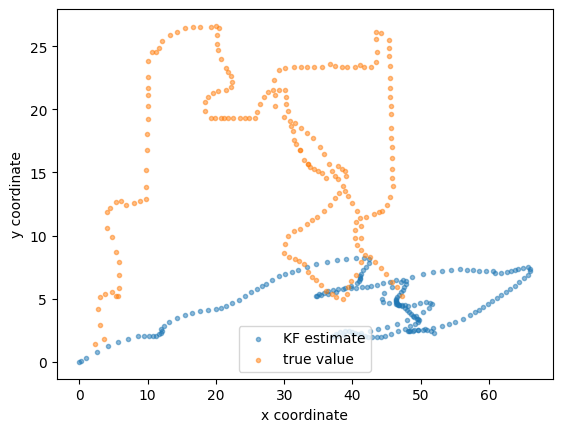

In [29]:
#change the code to 2 states instead of 4:
#I changed the states to 2 instead of 4 and adapted the kalman matrices below

kalman = cv2.KalmanFilter(2,2,0) # 2 states, 2 measurements, 0 control vector

q = 1 # the variance in the model
r = 20 # the variance in the measurement
dtime = 1 # size of time step

kalman.measurementMatrix = np.array([[1,0],[0,1]],np.float32) #  H
kalman.transitionMatrix = np.array([[1,dtime],
                                    [0,1]],np.float32) # A
kalman.processNoiseCov = np.array([[1,0],
                                   [0,1]],np.float32) * q # Q
kalman.measurementNoiseCov = np.array([[1,0],
                                       [0,1]],np.float32) * r # R

KF_estimate_xy = []

xy_motion = pd.read_csv('https://zenodo.org/records/10951538/files/kf_ts1.csv?download=1',
                        header = None).values.astype('float32')

for i in xy_motion:
    pred = kalman.predict()  # predicts new state using the model
    kalman.correct((i))      # updates estimated state with the measurement
    KF_estimate_xy.append(((pred[0]),(pred[1]))) # store the estimated position

x_est, y_est = zip(*KF_estimate_xy)
x_true, y_true = zip(*xy_motion)
plt.scatter(x_est, y_est, marker= '.', label = 'KF estimate', alpha = 0.5)
plt.scatter(x_true, y_true,marker= '.', label = 'true value', alpha = 0.5)
plt.legend(loc = 'lower center')
plt.xlabel('x coordinate')
plt.ylabel('y coordinate')

The kalman filter does not work well without velocity. The estimate is very bad as can be seen clearly in the plot. So it clearly needs the velocity to function properly. 

I changed the state vector to 2 dimensions as we only use positions x and y and no velocities. Then I changed the matrices for the kalman filter to include only states:

Measurement matrix $\mathbf{A} = \begin{bmatrix} 1 & 0  \\ 0 & 1  \end{bmatrix}$

Transition matrix $\mathbf{A} = \begin{bmatrix} 1 & \delta_t  \\ 0 & 1  \end{bmatrix}$ 

process noise covariance $\mathbf{A} = \begin{bmatrix} 1 & 0  \\ 0 & 1  \end{bmatrix}$ 

measurement noise covariance $\mathbf{A} = \begin{bmatrix} 1 & 0  \\ 0 & 1  \end{bmatrix}$ 

(so the size of all the matrices is 2x2 now)

## Chapter 08

### Exercise 1

- Combine (add) the [sine, trend, and noise](#signal-with-trend-and-noise) we defined earlier and obtain a singal composed of:
    * A sine wave representing seasonality.
    * a parabolic function representing a trend.
    * and uniformly distributed random noise.
- Plot the time and frequency domain components.

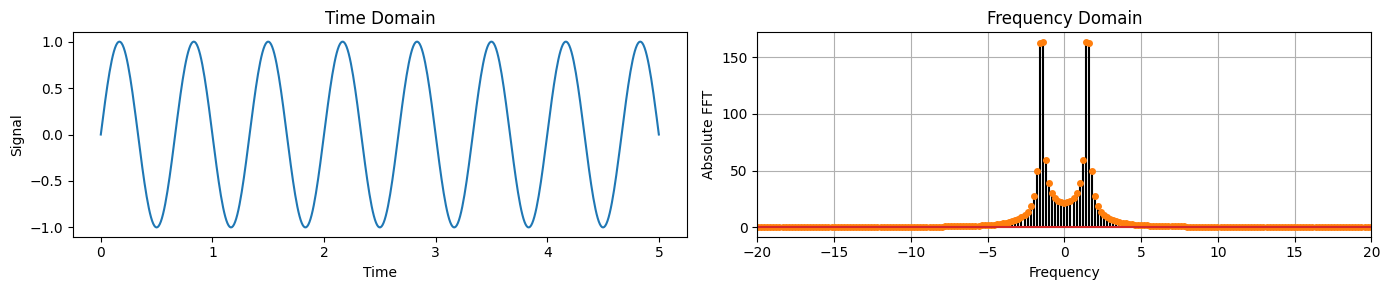

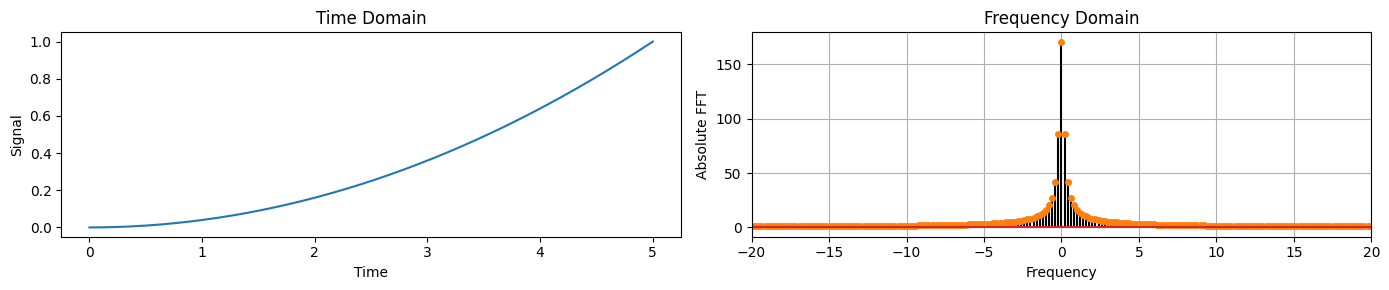

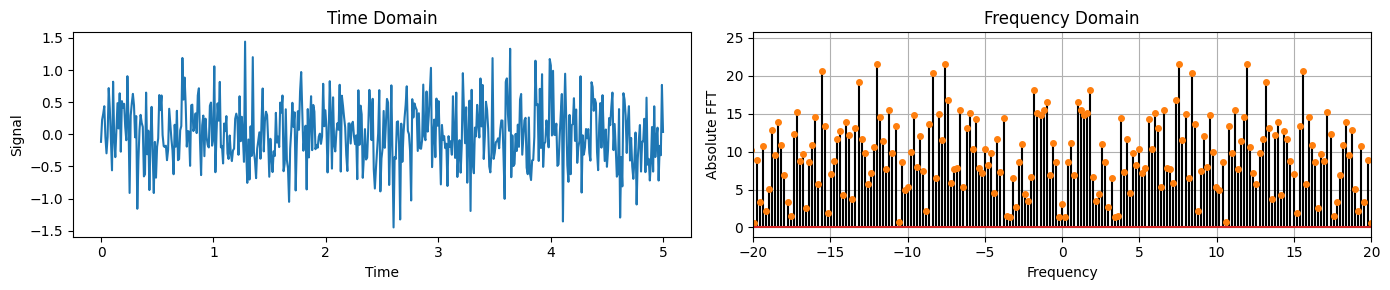

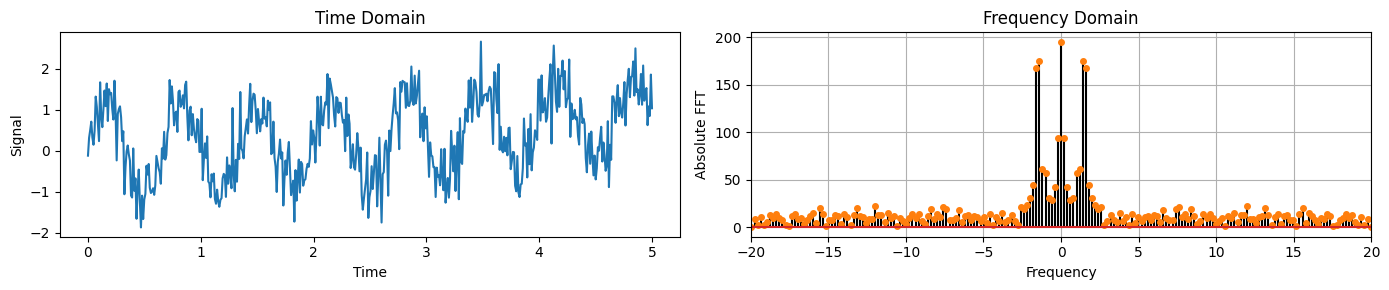

In [ ]:
def plot_time_freq(t, y):
    # Converts Data into Frequncy Domain
    freq = np.fft.fftfreq(t.size, d=t[1]-t[0])
    Y = abs(np.fft.fft(y))
    
    # Time domain plot
    plt.figure(figsize = [14,3])
    plt.subplot(1,2,1)
    plt.plot(t,y)
    plt.title('Time Domain')
    plt.xlabel('Time')
    plt.ylabel('Signal')
    
    # Frequency domain plot
    plt.subplot(1,2,2)
    markerline, stemline, baseline = plt.stem(np.fft.fftshift(freq),np.fft.fftshift(Y),
                                              'k', markerfmt='tab:orange')
    plt.setp(stemline, linewidth = 1.5)
    plt.setp(markerline, markersize = 4)
    plt.title('Frequency Domain')
    plt.xlabel('Frequency')
    plt.xlim(-20, 20)
    plt.ylabel('Absolute FFT')
    plt.grid()

    plt.tight_layout()
    plt.show()

time = np.linspace(0, 5, 512)
freq = 1.5

#seperate components of the signal
y_sine = np.sin(2 * np.pi * freq * time)
plot_time_freq(time, y_sine)
y_trend = (0.2 * time)**2
plot_time_freq(time, y_trend)
y_noise = 0.5 * np.random.randn(len(time))
plot_time_freq(time, y_noise)

#combined signal
comb_signal = y_sine + y_trend + y_noise
plot_time_freq(time, comb_signal)

- Modify the amplitude of the sine, trend, and noise components so that each component, in turn, dominates over the others. Comment on how the FT of the total signal changes.


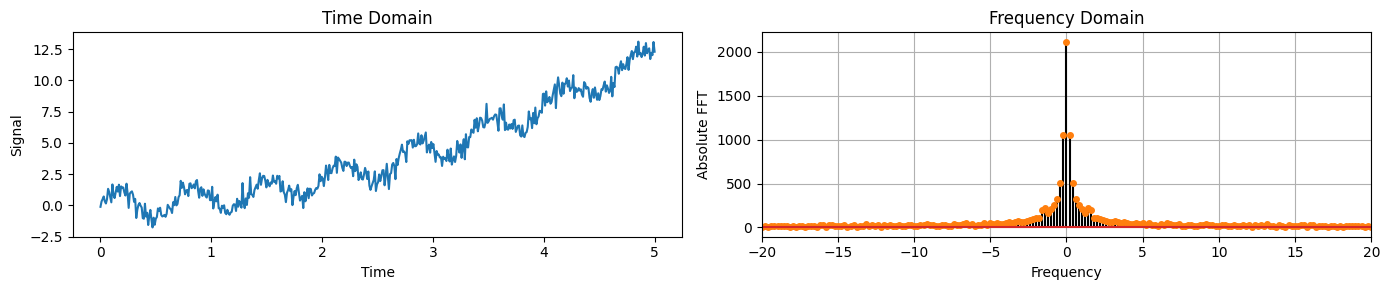

In [31]:
#signal with dominant trend:
y_trend = (0.7 * time)**2
comb_signal = y_sine + y_trend + y_noise
plot_time_freq(time, comb_signal)

The FT of the signal looks now almost like the FT of just the trend component, as the frequency of the trend components has a very high amplitude in comparison to the other components, which are now almost invisible in the FT, even though they are clearly visible in the time domain.

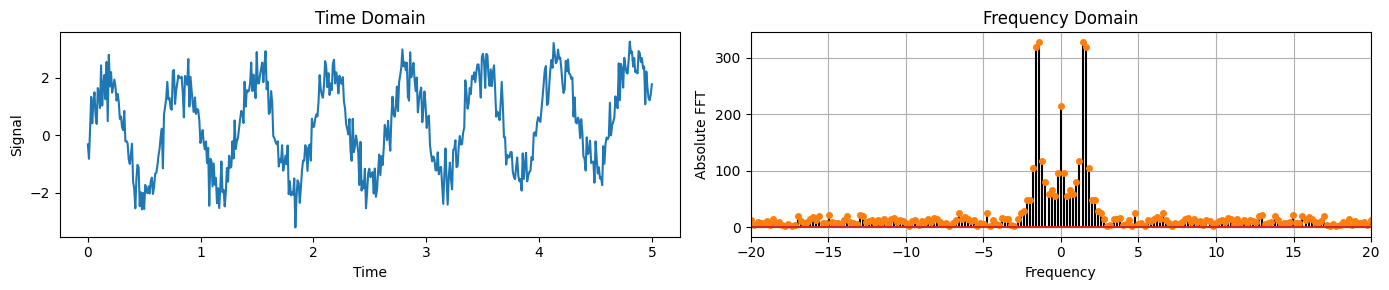

In [32]:
#signal with dominant seasonality
y_trend = (0.2 * time)**2
y_noise = 0.5 * np.random.randn(len(time))

y_sine = 2*np.sin(2 * np.pi * freq * time)

comb_signal = y_sine + y_trend + y_noise
plot_time_freq(time, comb_signal)

Now the frequency component of the seasonality is the most dominant, at $\pm$ 1.5 Hz. The noise is still a bit visible on the high frequencies and also the trend which is the spike around 0 in the FT is still there but less dominant than the sine component.

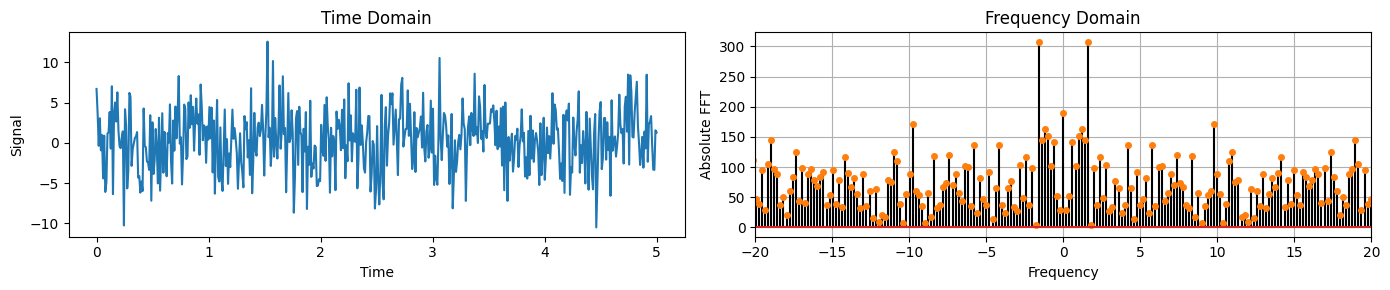

In [33]:
#signal with dominant noise
y_trend = (0.2 * time)**2
y_sine = np.sin(2 * np.pi * freq * time)

y_noise = 3.5 * np.random.randn(len(time))

comb_signal = y_sine + y_trend + y_noise
plot_time_freq(time, comb_signal)

Now the other two components, trend and seasonality, are virtually invisible, in both time domain and frequency domain, as the noise dominates. Compared to the FT of just the noise term, there is still some signature of the other components left at 0 and $\pm$ 1.5 Hz, but it would be hard to identifying it without knowing about it first.

- Modify the sine into a signal that is the sum of 2 sine waves of different amplitudes at 1 and 10 Hz as well as a constant term.  Make a plot in both time and frequency domains and comment the results.

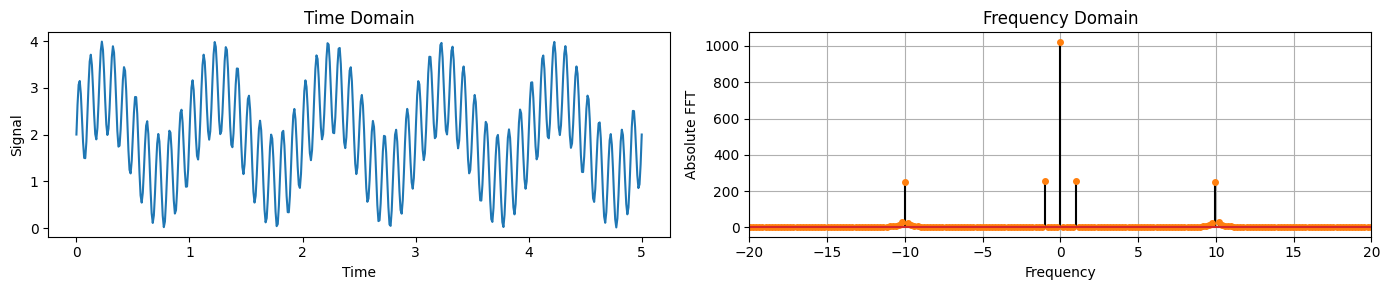

In [34]:
y_sine2 = np.sin(2 * np.pi * 1 * time) + np.sin(2 * np.pi * 10 * time) + 2
plot_time_freq(time, y_sine2)

Both frequencies of the added sine signal are clearly visible in frequency domain, there are clear spikes at $\pm$ 1Hz and $\pm$ 10 Hz. The spike with a high amplitude at 0 corresponds to the consant term. If I add a smaller constant the amplitude of that term in the FT will be smaller.

### Exercise 2

- Consider the following noisy signal:

In [35]:
time = np.linspace(0, 5, 512)
y_sine = 2*np.sin(2 * np.pi * 0.5 * time)
y_cos = 1.5*np.cos(2 * np.pi * 2.5 * time)
y_trend = (0.5 * time)**2
y_noise = 0.8 * np.random.randn(len(time))
y_signal = y_sine + y_cos + y_trend
noisy_signal = y_signal + y_noise

- Apply the [Tukey filter](#tukey-filter) to the `noisy_signal`.
- Modify the values `alpha` and `div_factor` of the filter to recover the clean signal `y_signal`.

Window length: 23


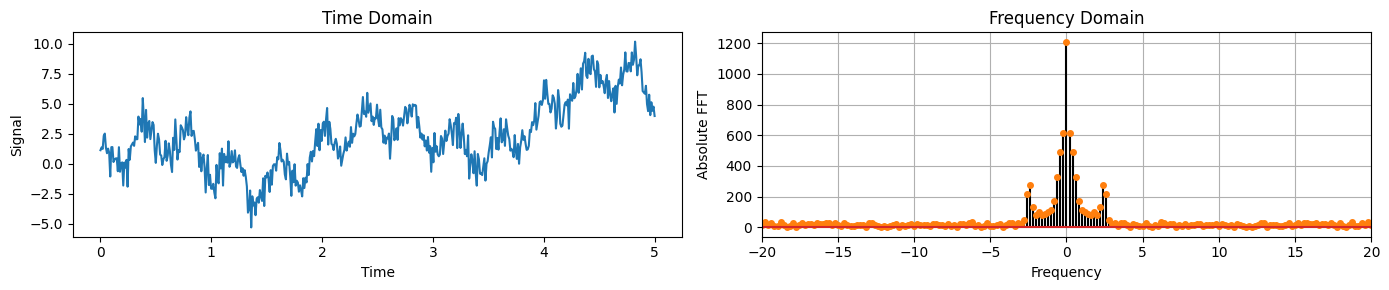

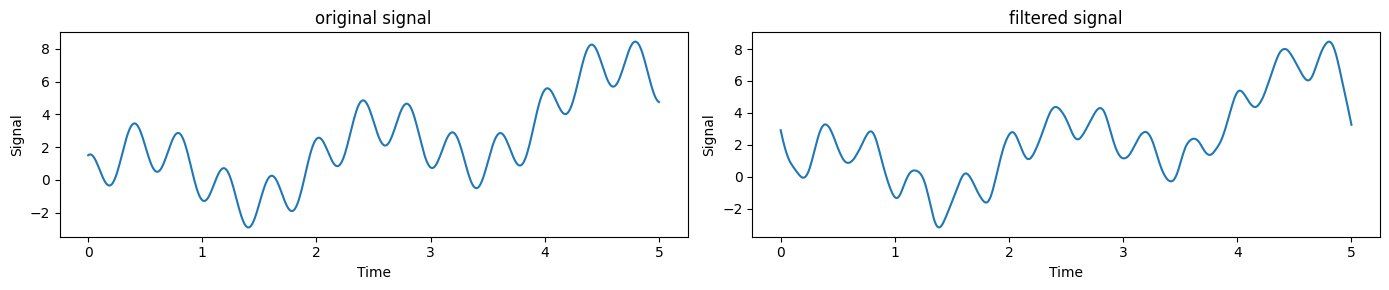

In [36]:
alpha= 1 # Filter's parameters
div_factor = 22 # use powers of 2
win_len = int(len(time) / div_factor)
print(f"Window length: {win_len}")

# Compute window
window_tukey = signal.windows.tukey(win_len, alpha=alpha)

# Compute frequency response
response_tukey = np.fft.fft(window_tukey, len(time))
response_tukey = np.abs(response_tukey / abs(response_tukey).max())

#noisy signal in freq domain
Y = np.fft.fft(noisy_signal)

# Apply filter in frequency domain and convert back to time domain
y_tukey = np.fft.ifft(Y*response_tukey)

#plot the result
plot_time_freq(time, noisy_signal)

plt.figure(figsize=[14,3])
plt.subplot(1,2,1)
plt.plot(time, y_signal)
plt.title('original signal')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.subplot(1,2,2)
plt.plot(time, y_tukey)
plt.title('filtered signal')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.tight_layout()
plt.show()

A window size between about 32 and 16 works, smaller doesn`t remove enough noise and larger removes too much of the signal and alters it. Acutally a window size of 22 is closest to the original signal (but its not a power of 2?), even though there is a little bit of noise still visible. A rectangular window ( alpha = 0) isn't so effective in creating a smooth signal, but something closer to a Hann window (alpha = 1) is. 

### Exercise 3

- Consider the `noisy_signal` from [Exercise 2](#exercise-2) .
- Now, your task is to recover `y_signal` using the [low-pass Butterworth filter](#butterworth-filter).
- Modify the filter order $N$ and cutoff frequency $\omega_c$ of the Butterworth filter.
- Which values seem to be the best in getting rid of the noise?

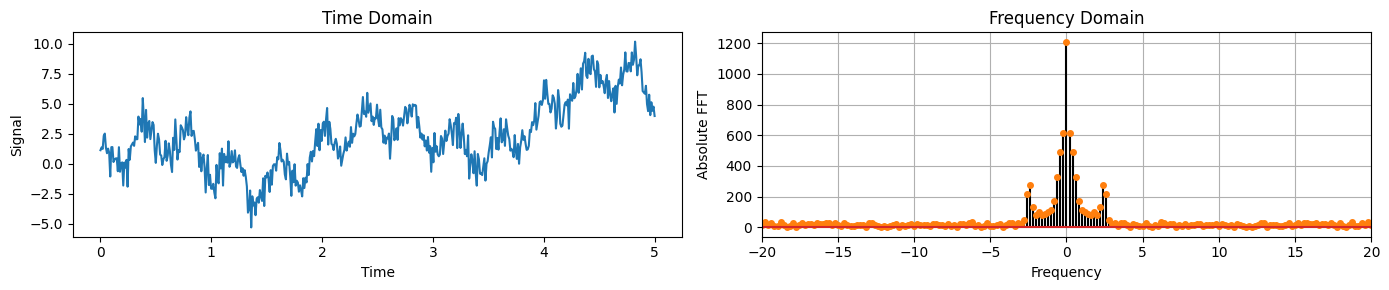

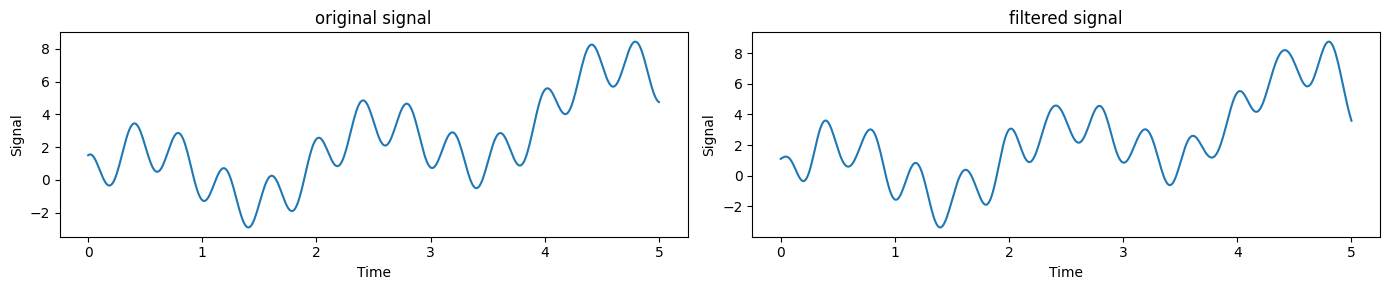

In [37]:
freq_c = 50

 # Numerator (B) and denominator (A) polynomials of the filter
B, A = signal.butter(N=9, Wn=freq_c, btype='lowpass', analog=False, fs=1234) 
 
# Apply the filter
y_low_butter = signal.filtfilt(B, A, noisy_signal)

plot_time_freq(time, noisy_signal)

plt.figure(figsize=[14,3])
plt.subplot(1,2,1)
plt.plot(time, y_signal)
plt.title('original signal')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.subplot(1,2,2)
plt.plot(time, y_low_butter)
plt.title('filtered signal')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.tight_layout()
plt.show()


This configuration of N = 9 and cutoff frequency = 50 rad/s which would be about 8 Hz almost perfectly reconstructs the signal without the noise. N = 9 would then be a quite steep roll-off of the filter. 

### Exercise 4

- Consider the `noisy_signal` from [Exercise 2](#exercise-2).
- Now, your task is to recover `y_signal` and then remove its trend component (`y_trend`).
- To do that, you will first apply the [high-pass Butterworth filter](#high-pass-filters-hpfs).
- Optimize, by hand, the filter order $N$ and cutoff frequency $\omega_c$ of the Butterworth filter.
- Then, apply the LPF in cascade to the HPF. 
- The result should contain neither trend nor noise.

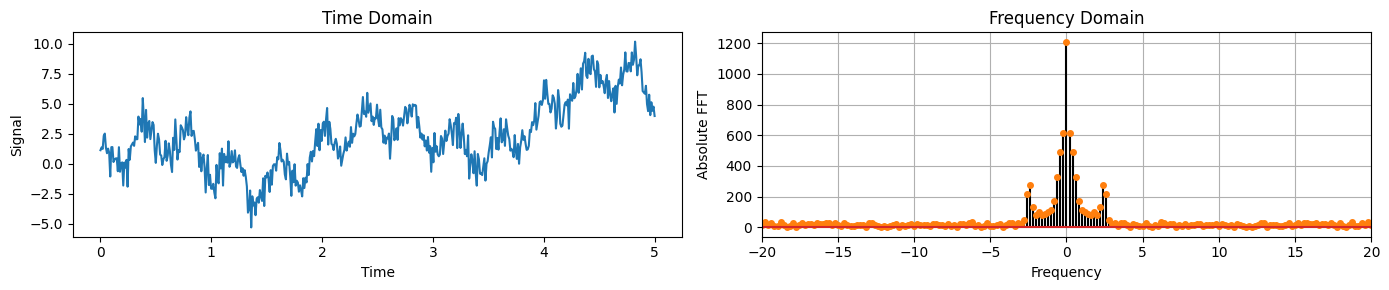

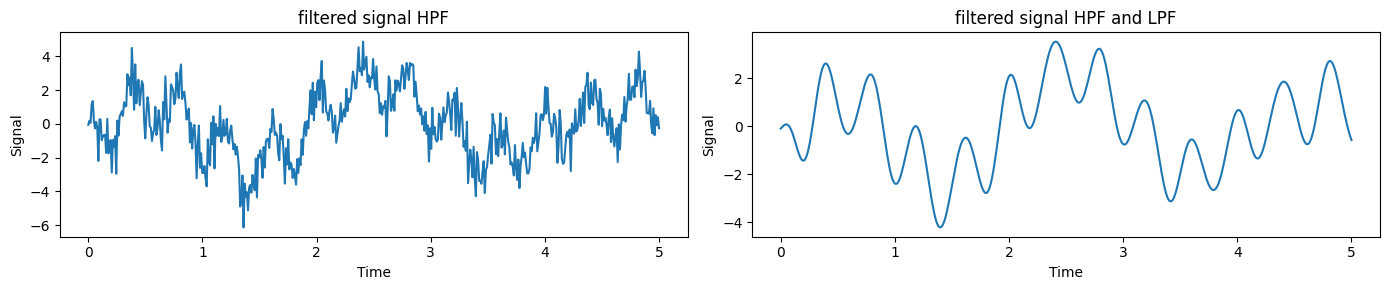

In [38]:
freq_c = 50
freq_c_high = 3

 # Numerator (B) and denominator (A) polynomials of the filter
B, A = signal.butter(N=9, Wn=freq_c, btype='lowpass', analog=False, fs=1234) 
B_high, A_high = signal.butter(N=7, Wn=freq_c_high, btype='highpass', analog=False, fs=1234) 
 
# Apply the filter
y_high_butter = signal.filtfilt(B_high, A_high, noisy_signal)
y_low_butter = signal.filtfilt(B, A, y_high_butter)

plot_time_freq(time, noisy_signal)

plt.figure(figsize=[14,3])
plt.subplot(1,2,1)
plt.plot(time, y_high_butter)
plt.title('filtered signal HPF')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.subplot(1,2,2)
plt.plot(time, y_low_butter)
plt.title('filtered signal HPF and LPF')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.tight_layout()
plt.show()

Now this should filter out all frequencies below 0.48 Hz and above 8 Hz. But then the roll-off of my highpass filter isn't as steep so there might be some other frequencies that are still present but get attenuated somewhat. Both periodic signal components are still left now, one higher frequency and one quite low frequency, but the trend is virtually gone. 

### Exercise 5

- Consider the `noisy_signal` from [Exercise 2](#exercise-2).
- Once again, your task is to recover `y_signal` and then remove its trend component (`y_trend`).
- Optimize, by hand, the filter order $N$ and the cutoff frequencies $\omega_c^\text{LOW}$ and $\omega_c^\text{HIGH}$ of the [band-pass Butterworth filter](#band-pass-filter).
- Compare the result of the BPF with what you got in [Exercise 4](#exercise-4) when you applied a HPF and LPF in cascade.

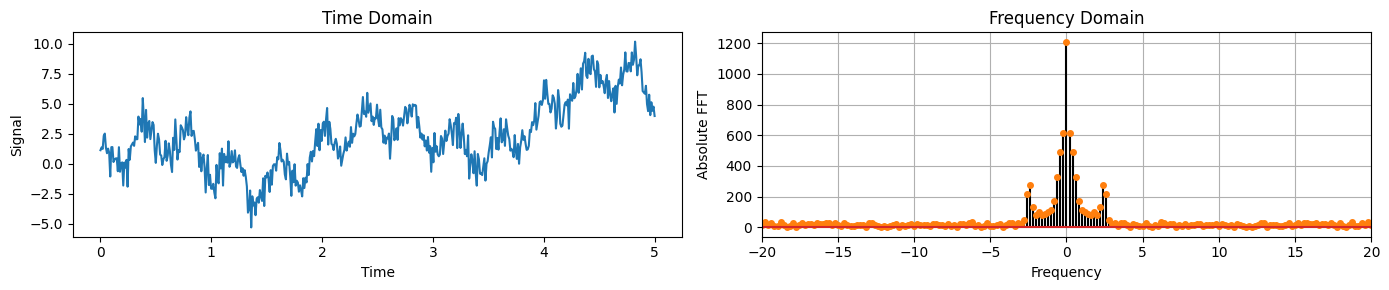

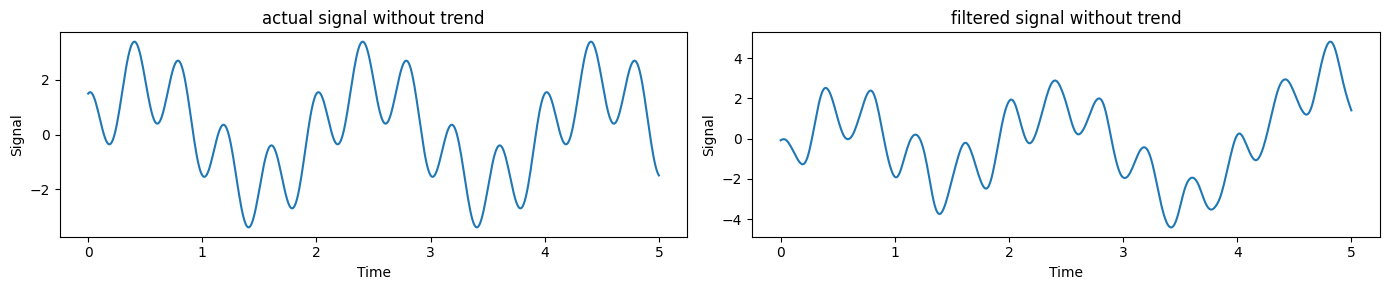

In [39]:
omega_c = [3, 50]
B_BP , A_BP  = signal.butter(N=2, Wn=omega_c, btype='bandpass', analog=False, fs=1234) 
BP_butter = signal.filtfilt(B_BP, A_BP, noisy_signal)

plot_time_freq(time, noisy_signal)

plt.figure(figsize=[14,3])
plt.subplot(1,2,1)
plt.plot(time, y_signal-y_trend)
plt.title('actual signal without trend')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.subplot(1,2,2)
plt.plot(time, BP_butter)
plt.title('filtered signal without trend')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.tight_layout()
plt.show()

The bandpass filter is doing reasonably well with the limits I used before when doing a cascade of filters when using a not too steep roll-off, like for example N = 4 or 2. It doesn't 100% give the original signal without the trend though. 

### Exercise 6

- Consider the `noisy_signal` from [Exercise 2](#exercise-2).
- This time, you will have to remove the component `y_cos` form the signal using the [band stop filter](#band-stop-filter).

15.707963267948966


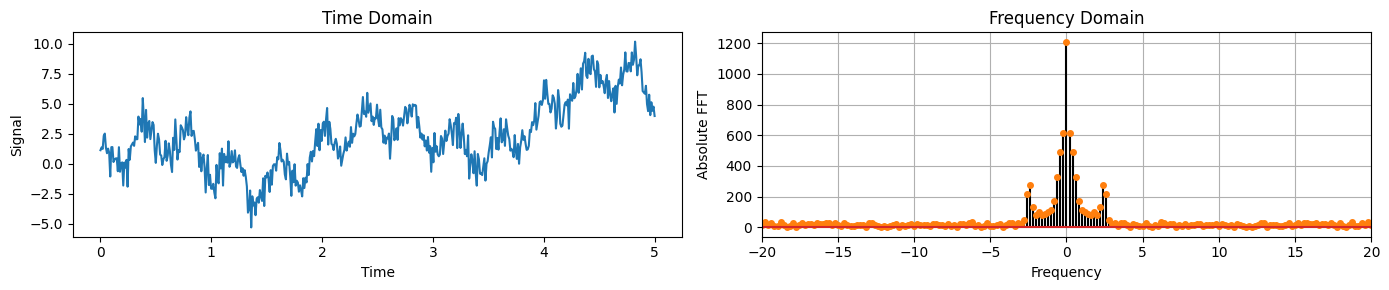

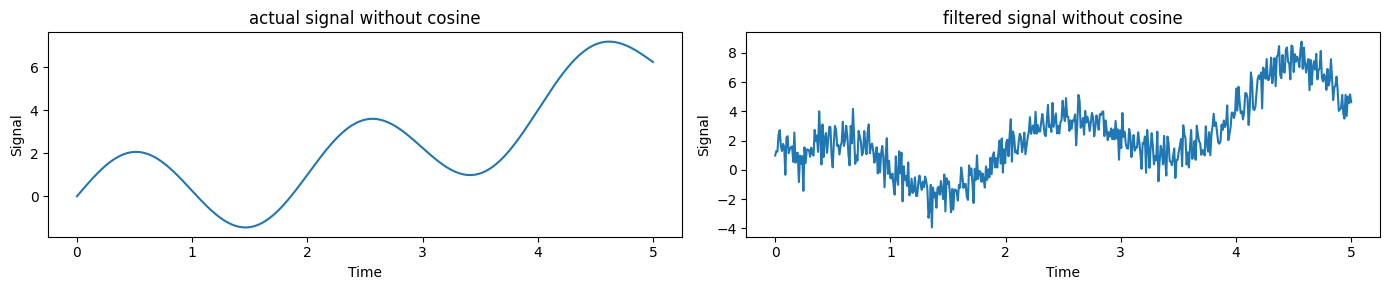

In [40]:
#remove cosine with frequency f = 2.5 Hz which is 
omega_cosine = 2.5 * 2 * np.pi
print(omega_cosine)
omega_c = [omega_cosine-1, omega_cosine+18]
#apply filter
B_BS , A_BS  = signal.butter(N=4, Wn=omega_c, btype='bandstop', analog=False, fs=1234) 
BS_butter = signal.filtfilt(B_BS, A_BS, noisy_signal)

plot_time_freq(time, noisy_signal)

plt.figure(figsize=[14,3])
plt.subplot(1,2,1)
plt.plot(time, y_signal-y_cos)
plt.title('actual signal without cosine')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.subplot(1,2,2)
plt.plot(time, BS_butter)
plt.title('filtered signal without cosine')
plt.xlabel('Time')
plt.ylabel('Signal')

plt.tight_layout()
plt.show()

I can either filter out just the cosine signal with centering the bandstop filter around that frequency of 2.5 Hz, or I can filter out the cosine AND a good deal of the noise by extending it to the high frequencies. (I'm not 100% sure what is asked in this question, but it sounds like keeping the noise). Above is my solution for filtering out just the cosine.

### Exercise 7

- Consider the CO2 data defined [here](#forecast-example-2).
- Divide the data in training and test.
- Identify the optimal number of harmonics that gives the best MSE on the test set.

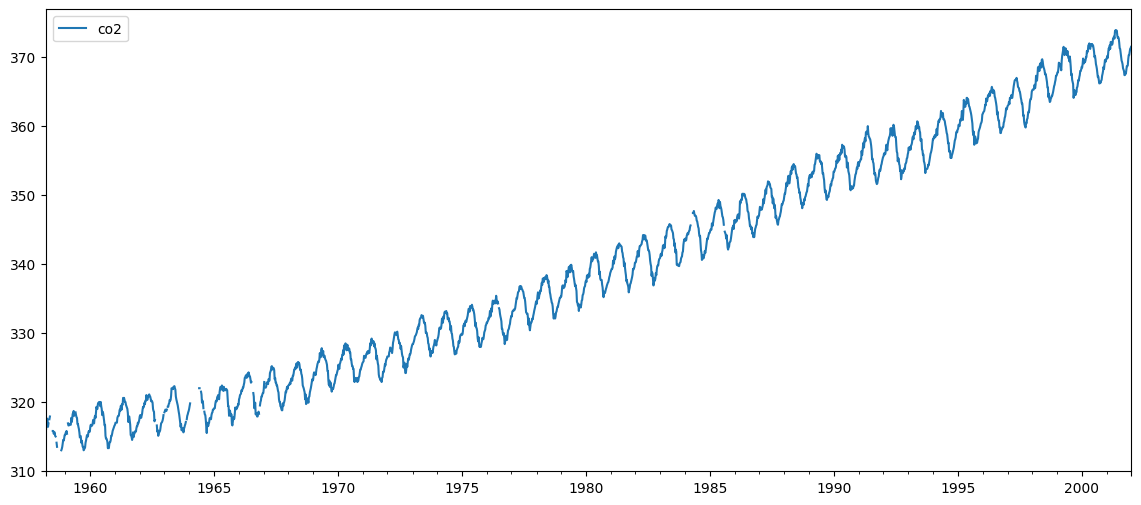

nr of harmonics: 0, MSE: 11.6
nr of harmonics: 1, MSE: 8.0
nr of harmonics: 2, MSE: 8.6
nr of harmonics: 3, MSE: 8.5
nr of harmonics: 4, MSE: 8.9
nr of harmonics: 5, MSE: 9.9
nr of harmonics: 6, MSE: 9.9
nr of harmonics: 7, MSE: 8.9
nr of harmonics: 8, MSE: 8.2
nr of harmonics: 9, MSE: 8.5
nr of harmonics: 10, MSE: 9.5
nr of harmonics: 11, MSE: 10.1
nr of harmonics: 12, MSE: 10.6
nr of harmonics: 13, MSE: 11.1
nr of harmonics: 14, MSE: 11.6
nr of harmonics: 15, MSE: 12.2
nr of harmonics: 16, MSE: 12.7
nr of harmonics: 17, MSE: 13.0
nr of harmonics: 18, MSE: 13.0
nr of harmonics: 19, MSE: 13.2


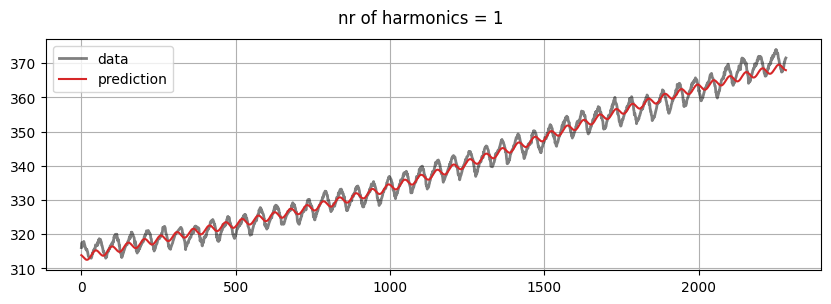

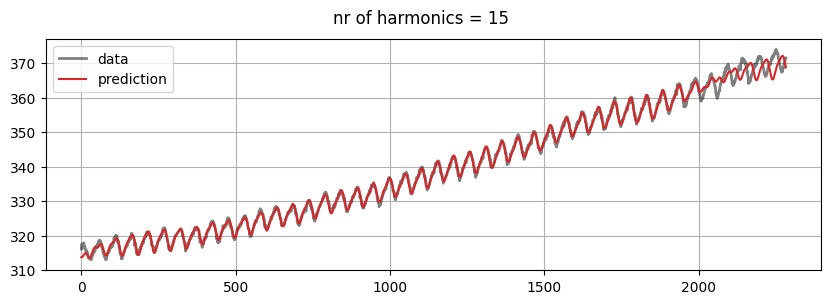

In [ ]:
#use Fourier Prediction function from the lectures
def fourierPrediction(y, n_predict, n_harm = 5):
    n = y.size                        # length of the time series
    t = np.arange(0, n)                # time vector
    p = np.polyfit(t, y, 1)            # find linear trend in x
    y_notrend = y - p[0] * t - p[1]    # detrended x
    y_freqdom = np.fft.fft(y_notrend)  # detrended x in frequency domain
    f = np.fft.fftfreq(n)              # frequencies
    
    # Sort indexes by largest frequency components
    indexes = np.argsort(np.absolute(y_freqdom))[::-1]

    t = np.arange(0, n + n_predict)
    restored_sig = np.zeros(t.size)
    for i in indexes[:1 + n_harm * 2]:
        amp = np.absolute(y_freqdom[i]) / n   # amplitude
        phase = np.angle(y_freqdom[i])        # phase
        restored_sig += amp * np.cos(2 * np.pi * f[i] * t + phase)
    return restored_sig + p[0] * t + p[1] # add back the trend

def fourierPredictionPlot(y, prediction, title):
    plt.figure(figsize=(10, 3))
    plt.suptitle(title)
    plt.plot(np.arange(0, y.size), y, 'k', label = 'data', linewidth = 2, alpha=0.5)
    plt.plot(np.arange(0, prediction.size), prediction, 'tab:red', label = 'prediction')
    plt.grid()
    plt.legend()
    plt.show()

#loading the data set with the code in the lecture gives me an error message for some weird reason,
#  so I try it another way:
co2 = sm.datasets.co2.load_pandas().data
co2.plot(figsize=(14,6))
plt.show()

#remove nan and interpolate, then create normal array out of pandas dataframe
#  and create time array
co2.dropna()
co2 = co2.interpolate()
co2_array = co2.values.ravel()
time = np.arange(0,len(co2_array), 1)

#divide into test and train sets (10% test)
stop = int(0.9*len(time))

co2_train = co2_array[:stop]
time_train = time[:stop]
co2_test = co2_array[stop:]
time_test = time[stop:]
n_pred = len(co2_test)

#calculate predictions for different number of hamonics with FT and calculate the mse for each:
predictions = []
MSE = []
for i in range(0,20):
    predict = fourierPrediction(co2_train, n_predict=n_pred, n_harm=i) 
    predictions.append( predict )
    MSE.append(mse(co2_test, predict[-n_pred:]))
    print(f"nr of harmonics: {i}, MSE: {MSE[i]:.1f}")

#create plots of two examples
fourierPredictionPlot(co2_array, predictions[1], "nr of harmonics = 1")
fourierPredictionPlot(co2_array, predictions[15], "nr of harmonics = 15")


Using a low number of harmonics seems to work better. Here n=1 does the best job according to the MSE. It is interesting that even just a flat line, n=0 seems to do better in predicting than a high number of harmonics, like n=15 for example. 

A higher number of harmonics is better in fitting the data we have, as can be seen when comparing the two plots above, but does very poorly in predictions. Maybe this has to do with overfitting? Lower harmonics models can`t fit the data as precisely but seem to be more robust for predictions.